# Этап 1: Парсинг Wikivoyage

In [1]:
!pip install -q mwparserfromhell requests tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.5/256.5 kB 6.2 MB/s eta 0:00:00


In [2]:
import os
import requests
from tqdm.notebook import tqdm

DUMP_URL = "https://dumps.wikimedia.org/enwikivoyage/latest/enwikivoyage-latest-pages-articles.xml.bz2"
DUMP_DIR = "/content/data"
DUMP_FILE = os.path.join(DUMP_DIR, "enwikivoyage.xml.bz2")

os.makedirs(DUMP_DIR, exist_ok=True)

if not os.path.exists(DUMP_FILE):
    print("Скачивание дампа Wikivoyage...")
    r = requests.get(DUMP_URL, stream=True)
    total = int(r.headers.get("content-length", 0))
    with open(DUMP_FILE, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as pbar:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))
    print(f"Дамп сохранён: {DUMP_FILE}")
else:
    print("Дамп уже скачан.")

Скачивание дампа Wikivoyage...


  0%|          | 0.00/129M [00:00<?, ?B/s]

Дамп сохранён: /content/data/enwikivoyage.xml.bz2


In [3]:
import bz2
import xml.etree.ElementTree as ET

def iter_wiki_pages(dump_path):
    """Генератор: выдаёт (title, text) для каждой статьи из namespace 0."""
    with bz2.open(dump_path, "rt", encoding="utf-8") as f:
        context = ET.iterparse(f, events=("end",))
        current_page = {}
        for event, elem in context:
            tag = elem.tag.split("}")[-1]
            if tag == "title":
                current_page["title"] = elem.text or ""
            elif tag == "text":
                current_page["text"] = elem.text or ""
            elif tag == "ns":
                current_page["ns"] = elem.text
            elif tag == "page":
                ns = current_page.get("ns", "")
                if ns == "0" and not current_page["text"].lower().startswith("#redirect"):
                    yield current_page["title"], current_page["text"]
                current_page = {}
                elem.clear()

In [4]:
import mwparserfromhell
import re

TARGET_SECTIONS = {
    "see":        "sights",
    "do":         "activities",
    "eat":        "food",
    "drink":      "drinks",
    "sleep":      "sleep",
    "get in":     "transport_in",
    "get around": "transport_local",
    "buy":        "shopping",
    "contact":    "contact",
    "cope":       "emergency",
    "understand": "understand",
    "go next":    "nearby",
}

def clean_wikitext(text):
    """Удаляет шаблоны, ссылки, разметку, оставляет чистый текст."""
    wikicode = mwparserfromhell.parse(text)

    templates = wikicode.filter_templates()
    for tpl in templates:
        try:
            wikicode.replace(tpl, "")
        except (ValueError, KeyError):
            pass

    tags = wikicode.filter_tags()
    for tag in tags:
        if tag.tag in ("ref", "gallery", "poem"):
            try:
                wikicode.replace(tag, "")
            except (ValueError, KeyError):
                pass

    text = str(wikicode)

    while "{{" in text and "}}" in text:
        text = re.sub(r"\{\{[^{}]*\}\}", "", text)

    text = re.sub(r"\[\[(File|Image|Media):[^\]]*\]\]", "", text, flags=re.IGNORECASE)
    text = re.sub(r"thumb\|[^|\]]*\|([^\]|]*)", r"\1", text, flags=re.IGNORECASE)
    text = re.sub(r"thumb\|([^\]|]*)", r"\1", text, flags=re.IGNORECASE)
    text = re.sub(r"\d+px\|", "", text)

    text = re.sub(r"\[\[[^|\]]*\|([^\]]+)\]\]", r"\1", text)
    text = re.sub(r"\[\[([^\]]+)\]\]", r"\1", text)

    text = re.sub(r"\[https?://[^\s\]]+\s+([^\]]+)\]", r"\1", text)
    text = re.sub(r"\[https?://[^\s\]]+\]", "", text)

    text = re.sub(r"\[\[(Category|File|Image|Media):[^\]]+\]\]", "", text, flags=re.IGNORECASE)

    text = re.sub(r"<[^>]+>", "", text)

    text = re.sub(r"^\s*\*+\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"^\s*#+\s*", "", text, flags=re.MULTILINE)

    text = re.sub(r"'{2,}", "", text)

    text = re.sub(r"-{4,}", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [5]:
def extract_sections(title, text):
    """Извлекает целевые разделы из статьи."""
    try:
        wikicode = mwparserfromhell.parse(text)
    except Exception:
        return []

    results = []
    current_section = None
    current_buffer = []

    for node in wikicode.nodes:
        if isinstance(node, mwparserfromhell.nodes.heading.Heading):
            if current_section is not None and current_buffer:
                try:
                    clean = clean_wikitext("".join(current_buffer))
                    if len(clean) > 50:
                        results.append((current_section, clean))
                except Exception:
                    pass
            current_buffer = []

            level = node.level
            try:
                section_title = str(node.title).strip().lower()
            except Exception:
                current_section = None
                continue

            if level == 2 and section_title in TARGET_SECTIONS:
                current_section = TARGET_SECTIONS[section_title]
            else:
                current_section = None
        else:
            if current_section is not None:
                current_buffer.append(str(node))

    if current_section is not None and current_buffer:
        try:
            clean = clean_wikitext("".join(current_buffer))
            if len(clean) > 50:
                results.append((current_section, clean))
        except Exception:
            pass

    return results

In [6]:
import json
import os
import time
from tqdm.notebook import tqdm

OUTPUT_FILE = os.path.join(DUMP_DIR, "wikivoyage_kb.jsonl")
STATS_FILE = os.path.join(DUMP_DIR, "wikivoyage_kb_stats.json")
CHECKPOINT_DIR = os.path.join(DUMP_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SAVE_EVERY = 10000
ESTIMATED_TOTAL = 30000

# Состояние
stats = {
    "pages_processed": 0,
    "pages_with_sections": 0,
    "sections_extracted": 0,
    "last_checkpoint_at": 0,
    "start_time": time.time(),
}

def load_last_checkpoint_title():
    """Возвращает название последней обработанной статьи, если есть checkpoint."""
    if not os.path.exists(STATS_FILE):
        return None
    try:
        with open(STATS_FILE, "r", encoding="utf-8") as f:
            data = json.load(f)
            return data.get("last_title", None)
    except Exception:
        return None

resume_from_title = None
file_mode = "a" if resume_from_title and os.path.exists(OUTPUT_FILE) else "w"

processed = 0

try:
    with open(OUTPUT_FILE, file_mode, encoding="utf-8", buffering=1) as out:
        pbar = tqdm(
            iter_wiki_pages(DUMP_FILE),
            desc="Парсинг Wikivoyage",
            unit="стр.",
            total=ESTIMATED_TOTAL,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}",
        )

        for title, text in pbar:
            if resume_from_title is not None:
                if title != resume_from_title:
                    processed += 1
                    continue
                else:
                    resume_from_title = None  # дошли — дальше обрабатываем

            stats["pages_processed"] += 1
            processed += 1

            try:
                sections = extract_sections(title, text)
            except Exception as e:
                pbar.set_postfix_str(f"ошибка в '{title[:30]}': {str(e)[:40]}")
                continue

            if not sections:
                continue

            stats["pages_with_sections"] += 1

            for section_key, section_text in sections:
                stats["sections_extracted"] += 1
                record = {
                    "id": f"{stats['sections_extracted'] - 1}",
                    "title": title,
                    "section": section_key,
                    "text": section_text,
                }
                out.write(json.dumps(record, ensure_ascii=False) + "\n")

            pbar.set_postfix({
                "разделов": stats["sections_extracted"],
                "с разделами": stats["pages_with_sections"],
            })

            if stats["pages_processed"] % SAVE_EVERY == 0:
                out.flush()

                stats["last_checkpoint_at"] = stats["pages_processed"]
                stats["last_title"] = title
                stats["elapsed_sec"] = time.time() - stats["start_time"]

                with open(STATS_FILE, "w", encoding="utf-8") as sf:
                    json.dump(stats, sf, indent=2, ensure_ascii=False)

                checkpoint_file = os.path.join(
                    CHECKPOINT_DIR,
                    f"wikivoyage_kb_at_{stats['pages_processed']}.jsonl"
                )

                import shutil
                shutil.copyfile(OUTPUT_FILE, checkpoint_file)

                pbar.set_postfix_str(
                    f"checkpoint @ {stats['pages_processed']} стр., "
                    f"{stats['sections_extracted']} разделов"
                )

                print(f"\n[Checkpoint] Сохранено @ {stats['pages_processed']} страниц, "
                      f"{stats['sections_extracted']} разделов. "
                      f"Файл: {checkpoint_file}")

except KeyboardInterrupt:
    print("\n\nПрервано пользователем. Сохраняем текущее состояние...")
    stats["interrupted"] = True
    stats["elapsed_sec"] = time.time() - stats["start_time"]
    with open(STATS_FILE, "w", encoding="utf-8") as sf:
        json.dump(stats, sf, indent=2, ensure_ascii=False)
    print(f"Статистика сохранена в {STATS_FILE}")
    print(f"Данные сохранены в {OUTPUT_FILE}")

stats["elapsed_sec"] = time.time() - stats["start_time"]
stats["finished"] = True
with open(STATS_FILE, "w", encoding="utf-8") as sf:
    json.dump(stats, sf, indent=2, ensure_ascii=False)


Парсинг Wikivoyage:   0%|          | 0/30000 [00:00<?, ?стр./s] 


[Checkpoint] Сохранено @ 10000 страниц, 38457 разделов. Файл: /content/data/checkpoints/wikivoyage_kb_at_10000.jsonl


Прервано пользователем. Сохраняем текущее состояние...
Статистика сохранена в /content/data/wikivoyage_kb_stats.json
Данные сохранены в /content/data/wikivoyage_kb.jsonl


In [7]:
import pandas as pd

df = pd.read_json(OUTPUT_FILE, lines=True)
print(f"Всего записей (разделов): {len(df)}")
print(f"Уникальных статей: {df['title'].nunique()}")
print(f"\nРаспределение по разделам:")
print(df["section"].value_counts())
print(f"\nПример записи:")
sample = df.sample(1).iloc[0]
print(f"Статья: {sample['title']}")
print(f"Раздел: {sample['section']}")
print(f"Текст (первые 500 символов):\n{sample['text'][:500]}...")

Всего записей (разделов): 86326
Уникальных статей: 19507

Распределение по разделам:
section
understand         11798
nearby             10220
transport_local     9700
activities          9064
sights              8628
food                8624
transport_in        8513
shopping            6867
drinks              6347
sleep               6021
emergency            540
contact                4
Name: count, dtype: int64

Пример записи:
Статья: Taebaek
Раздел: drinks
Текст (первые 500 символов):
There are several Korean hof, one dancing establishment and one Korean/Western bar in Taebaek. Village of Aroma: A place where you can savor various types of craft beers and traditional liquors. It's an opportunity to taste locally-produced drinks and engage with the local culture. Scent of the Sky: A sophisticated bar offering a range of wines and cocktails. Particularly during sunset, you can enjoy a beautiful view while sipping on your drink. Cafe and Wine Bar: Combining the elements of a caf...


# Этап 2: Построение векторного индекса и эксперименты по качеству

In [8]:
!pip install -q langchain langchain-community langchain-chroma chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6

In [24]:
import pandas as pd
import os

KB_FILE = "/content/data/wikivoyage_kb.jsonl"
df = pd.read_json(KB_FILE, lines=True)

print(f"Всего записей (разделов): {len(df)}")
print(f"Уникальных статей: {df['title'].nunique()}")
print(f"\nРаспределение длин исходных текстов (символы):")
print(df["text"].apply(len).describe())

Всего записей (разделов): 86326
Уникальных статей: 19507

Распределение длин исходных текстов (символы):
count    86326.000000
mean       548.497625
std        739.272576
min         51.000000
25%        160.000000
50%        321.000000
75%        663.000000
max      51435.000000
Name: text, dtype: float64


In [25]:
import numpy as np
from scipy import stats
from typing import List, Dict

def evaluate_chunk_distribution(chunks: List[str], target_size: int) -> Dict[str, float]:
    """
    Считает метрики качества распределения длин чанков.

    - pct_in_10pct_range: доля чанков в пределах ±10% от target (чем больше — тем лучше)
    - coefficient_of_variation: CV = std/mean (чем меньше — тем ровнее)
    - skewness: асимметрия распределения (близкая к 0 — симметрично)
    - mean_error_pct: насколько среднее отклоняется от target (%)
    - pct_outliers: доля чанков меньше 0.5*target или больше 1.5*target
    - iqr_pct_of_target: межквартильный размах как доля от target
    """
    lengths = np.array([len(c) for c in chunks])
    n = len(lengths)
    if n == 0:
        return {}

    in_range = np.sum((lengths >= 0.9 * target_size) & (lengths <= 1.1 * target_size))
    pct_in_range = 100 * in_range / n

    cv = np.std(lengths) / np.mean(lengths) if np.mean(lengths) > 0 else 0
    skew = stats.skew(lengths) if n > 2 else 0.0

    mean_error_pct = 100 * (np.mean(lengths) - target_size) / target_size

    outliers = np.sum((lengths < 0.5 * target_size) | (lengths > 1.5 * target_size))
    pct_outliers = 100 * outliers / n

    q1, q3 = np.percentile(lengths, [25, 75])
    iqr_pct_of_target = 100 * (q3 - q1) / target_size

    return {
        "n_chunks": int(n),
        "mean_len": float(np.mean(lengths)),
        "median_len": float(np.median(lengths)),
        "min_len": int(np.min(lengths)),
        "max_len": int(np.max(lengths)),
        "std_len": float(np.std(lengths)),
        "pct_in_10pct_range": float(pct_in_range),
        "coefficient_of_variation": float(cv),
        "skewness": float(skew),
        "mean_error_pct": float(mean_error_pct),
        "pct_outliers": float(pct_outliers),
        "iqr_pct_of_target": float(iqr_pct_of_target),
    }

In [33]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
)

# Сетки параметров
SPLITTERS = {
    "Recursive": lambda size, overlap: RecursiveCharacterTextSplitter(
        separators=["\n\n", "\n", ". ", " ", ""],
        chunk_size=size,
        chunk_overlap=overlap,
        length_function=len,
    ),
}

CHUNK_SIZES = [200, 300, 400, 800]
CHUNK_OVERLAPS = [30, 50, 100, 200]

# Все комбинации (исключаем бессмысленные, где overlap >= size/2)
configs = []
for splitter_name, splitter_fn in SPLITTERS.items():
    for size in CHUNK_SIZES:
        for overlap in CHUNK_OVERLAPS:
            if overlap >= size // 2:
                continue
            configs.append({
                "splitter": splitter_name,
                "chunk_size": size,
                "chunk_overlap": overlap,
                "splitter_fn": splitter_fn,
            })

print(f"Всего конфигураций для тестирования: {len(configs)}")

Всего конфигураций для тестирования: 12


In [34]:
import time

results = []

all_texts = df["text"].tolist()

for i, config in enumerate(configs):
    label = f"{config['splitter']:10s} size={config['chunk_size']:4d} overlap={config['chunk_overlap']:3d}"
    print(f"\n[{i+1}/{len(configs)}] {label}")

    t0 = time.time()

    splitter = config["splitter_fn"](config["chunk_size"], config["chunk_overlap"])

    all_chunks = []
    for text in all_texts:
        try:
            chunks = splitter.split_text(text)
            all_chunks.extend(chunks)
        except Exception:
            if text.strip():
                all_chunks.append(text)

    metrics = evaluate_chunk_distribution(all_chunks, config["chunk_size"])
    elapsed = time.time() - t0

    row = {
        "splitter": config["splitter"],
        "chunk_size": config["chunk_size"],
        "chunk_overlap": config["chunk_overlap"],
        "time_sec": elapsed,
    }
    row.update(metrics)
    results.append(row)

    print(f"  Чанков: {metrics['n_chunks']:6d}, "
          f"в ±10%: {metrics['pct_in_10pct_range']:5.1f}%, "
          f"CV: {metrics['coefficient_of_variation']:.3f}, "
          f"выбросов: {metrics['pct_outliers']:5.1f}%, "
          f"время: {elapsed:.1f}с")

df_results = pd.DataFrame(results)
print(f"\nУспешно протестировано конфигураций: {len(df_results)}")


[1/12] Recursive  size= 200 overlap= 30
  Чанков: 348795, в ±10%:  24.4%, CV: 0.331, выбросов:  21.9%, время: 3.8с

[2/12] Recursive  size= 200 overlap= 50
  Чанков: 352135, в ±10%:  24.9%, CV: 0.310, выбросов:  20.4%, время: 2.9с

[3/12] Recursive  size= 300 overlap= 30
  Чанков: 231087, в ±10%:  21.7%, CV: 0.337, выбросов:  22.8%, время: 1.9с

[4/12] Recursive  size= 300 overlap= 50
  Чанков: 232565, в ±10%:  21.9%, CV: 0.330, выбросов:  22.3%, время: 1.9с

[5/12] Recursive  size= 300 overlap=100
  Чанков: 244711, в ±10%:  23.1%, CV: 0.303, выбросов:  18.7%, время: 2.2с

[6/12] Recursive  size= 400 overlap= 30
  Чанков: 178265, в ±10%:  21.9%, CV: 0.383, выбросов:  27.7%, время: 2.9с

[7/12] Recursive  size= 400 overlap= 50
  Чанков: 178945, в ±10%:  22.0%, CV: 0.380, выбросов:  27.5%, время: 1.7с

[8/12] Recursive  size= 400 overlap=100
  Чанков: 185066, в ±10%:  22.8%, CV: 0.359, выбросов:  25.0%, время: 1.7с

[9/12] Recursive  size= 800 overlap= 30
  Чанков: 114675, в ±10%:  18.5

In [35]:

df_results["score"] = (
    df_results["pct_in_10pct_range"]
    - 50 * df_results["coefficient_of_variation"]
    - df_results["pct_outliers"]
)

df_show = df_results[["splitter", "chunk_size", "chunk_overlap",
                      "n_chunks", "pct_in_10pct_range",
                      "coefficient_of_variation", "pct_outliers",
                      "mean_error_pct", "score"]].copy()
df_show = df_show.sort_values("score", ascending=False)

print("\nТоп-10 конфигураций по качеству распределения:")
print(df_show.head(10).to_string(index=False, float_format="%.2f"))

print("\nХудшие 5 конфигураций:")
print(df_show.tail(5).to_string(index=False, float_format="%.2f"))

best = df_show.iloc[0]
print(f"\nЛучшая конфигурация:")
print(f"  Сплиттер:            {best['splitter']}")
print(f"  chunk_size:          {best['chunk_size']}")
print(f"  chunk_overlap:       {best['chunk_overlap']}")
print(f"  Всего чанков:        {best['n_chunks']}")
print(f"  В пределах ±10%:     {best['pct_in_10pct_range']:.2f}%")
print(f"  Коэф. вариации:      {best['coefficient_of_variation']:.3f}")
print(f"  Доля выбросов:       {best['pct_outliers']:.2f}%")
print(f"  Ошибка среднего:     {best['mean_error_pct']:.2f}%")


Топ-10 конфигураций по качеству распределения:
 splitter  chunk_size  chunk_overlap  n_chunks  pct_in_10pct_range  coefficient_of_variation  pct_outliers  mean_error_pct  score
Recursive         300            100    244711               23.06                      0.30         18.68          -28.93 -10.77
Recursive         200             50    352135               24.87                      0.31         20.39          -29.64 -11.02
Recursive         200             30    348795               24.40                      0.33         21.85          -30.75 -14.02
Recursive         300             50    232565               21.89                      0.33         22.32          -31.01 -16.96
Recursive         300             30    231087               21.72                      0.34         22.81          -31.35 -17.94
Recursive         400            100    185066               22.81                      0.36         24.97          -31.77 -20.11
Recursive         400             50    17

In [41]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
import numpy as np

CHUNK_SIZE = 500
CHUNK_OVERLAP = 100

splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
)

print(f"Применяем RecursiveCharacterTextSplitter:")
print(f"  chunk_size:    {CHUNK_SIZE}")
print(f"  chunk_overlap: {CHUNK_OVERLAP}")

final_docs = []
chunks_per_article = []

for _, row in df.iterrows():
    try:
        chunks = splitter.split_text(row["text"])
    except Exception:
        chunks = [row["text"]] if row["text"].strip() else []

    chunks_per_article.append(len(chunks))

    for i, chunk in enumerate(chunks):
        if not chunk.strip():
            continue
        final_docs.append(Document(
            page_content=chunk,
            metadata={
                "title": row["title"],
                "section": row["section"],
                "chunk_id": i,
                "source_id": row["id"],
            },
        ))

print(f"\nИтого чанков: {len(final_docs)}")
print(f"Чанков на статью: среднее={np.mean(chunks_per_article):.2f}, "
      f"медиана={np.median(chunks_per_article):.1f}, макс={max(chunks_per_article)}")

Применяем RecursiveCharacterTextSplitter:
  chunk_size:    500
  chunk_overlap: 100

Итого чанков: 153762
Чанков на статью: среднее=1.78, медиана=1.0, макс=127



Статистика длин чанков:
  Средняя длина:  322.0 символов
  Медианная:      358.0 символов
  Мин / Макс:     3 / 500
  Стандартное отклонение: 136.2


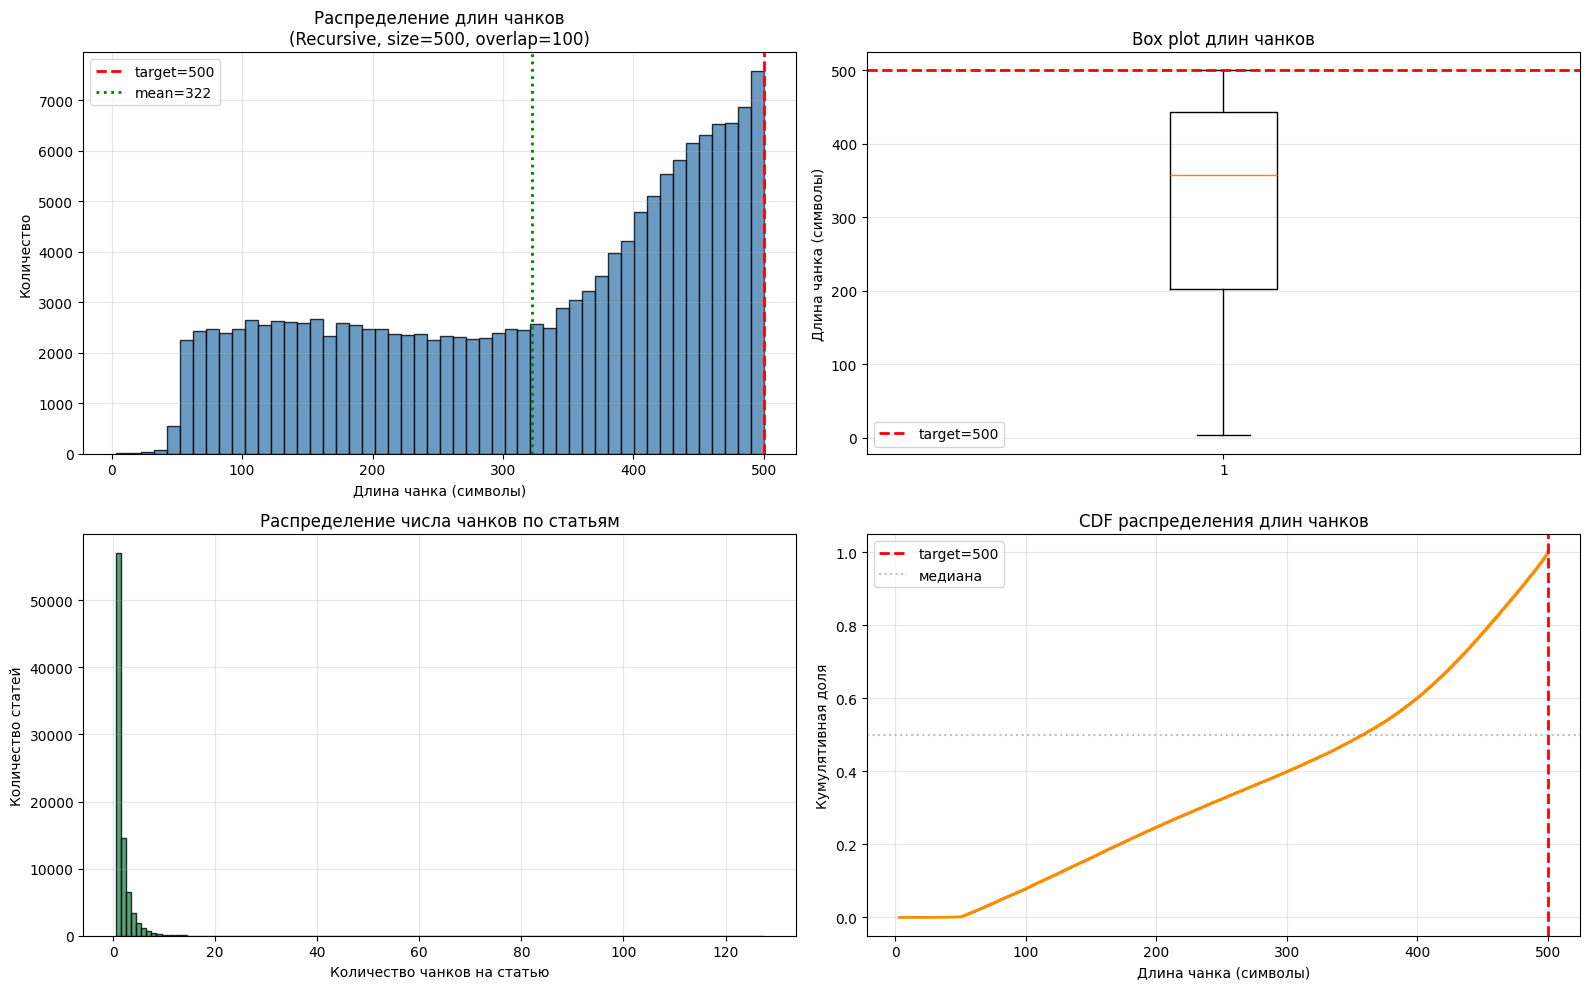

In [45]:
import matplotlib.pyplot as plt

lengths = [len(doc.page_content) for doc in final_docs]

print(f"\nСтатистика длин чанков:")
print(f"  Средняя длина:  {np.mean(lengths):.1f} символов")
print(f"  Медианная:      {np.median(lengths):.1f} символов")
print(f"  Мин / Макс:     {min(lengths)} / {max(lengths)}")
print(f"  Стандартное отклонение: {np.std(lengths):.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(lengths, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
axes[0, 0].axvline(CHUNK_SIZE, color="red", linestyle="--", linewidth=2, label=f"target={CHUNK_SIZE}")
axes[0, 0].axvline(np.mean(lengths), color="green", linestyle=":", linewidth=2, label=f"mean={np.mean(lengths):.0f}")
axes[0, 0].set_xlabel("Длина чанка (символы)")
axes[0, 0].set_ylabel("Количество")
axes[0, 0].set_title(f"Распределение длин чанков\n(Recursive, size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(lengths, vert=True)
axes[0, 1].axhline(CHUNK_SIZE, color="red", linestyle="--", linewidth=2, label=f"target={CHUNK_SIZE}")
axes[0, 1].set_ylabel("Длина чанка (символы)")
axes[0, 1].set_title("Box plot длин чанков")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis="y")

# 3. Чанков на статью
axes[1, 0].hist(chunks_per_article, bins=range(1, max(chunks_per_article)+2),
                color="seagreen", edgecolor="black", alpha=0.8, align="left")
axes[1, 0].set_xlabel("Количество чанков на статью")
axes[1, 0].set_ylabel("Количество статей")
axes[1, 0].set_title("Распределение числа чанков по статьям")
axes[1, 0].grid(alpha=0.3)

# 4. CDF
sorted_lengths = np.sort(lengths)
cdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1, 1].plot(sorted_lengths, cdf, color="darkorange", linewidth=2)
axes[1, 1].axvline(CHUNK_SIZE, color="red", linestyle="--", linewidth=2, label=f"target={CHUNK_SIZE}")
axes[1, 1].axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="медиана")
axes[1, 1].set_xlabel("Длина чанка (символы)")
axes[1, 1].set_ylabel("Кумулятивная доля")
axes[1, 1].set_title("CDF распределения длин чанков")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
max_chunks_record = None
max_chunks_count = 0

for _, row in df.iterrows():
    chunks = splitter.split_text(row["text"])
    if len(chunks) > max_chunks_count:
        max_chunks_count = len(chunks)
        max_chunks_record = row

print(f"Самый длинный раздел:")
print(f"  Статья: {max_chunks_record['title']}")
print(f"  Раздел: {max_chunks_record['section']}")
print(f"  Длина: {len(max_chunks_record['text'])} символов")
print(f"  Чанков: {max_chunks_count}")
print(f"  Превью: {max_chunks_record['text'][:300]}...")

Самый длинный раздел:
  Статья: Titanic
  Раздел: understand
  Длина: 51435 символов
  Чанков: 127
  Превью: Nowadays, most people cross the Atlantic by air. But the first transatlantic flight was not until 1919, and commercial flights only began in the late 1930s, only to be interrupted by wartime shortly thereafter. These early flights combined the expense of first-class liners with the comfort of third-...


In [226]:
for i in range(3):
    doc = final_docs[i]
    print(f"\n--- Чанк {i+1} ---")
    print(f"Статья: {doc.metadata['title']}")
    print(f"Раздел: {doc.metadata['section']}")
    print(f"Длина: {len(doc.page_content)} символов")
    print(f"Текст:\n{doc.page_content[:300]}...")


--- Чанк 1 ---
Статья: 's-Hertogenbosch
Раздел: understand
Длина: 269 символов
Текст:
Located where the rivers Aa and Dommel meet, the city of 's-Hertogenbosch became a city in 1184. It is one of the foremost cities of the historic Duchy of Brabant (1183 - 1794), which roughly consisted of the Dutch province of Noord-Brabant and large pieces of Flanders...

--- Чанк 2 ---
Статья: 's-Hertogenbosch
Раздел: understand
Длина: 408 символов
Текст:
. Being one of the first cities founded in the Low Countries during the Mediaeval period, the charter which granted Den Bosch its city rights was subsequently used and adapted by a lot of other newly founded cities throughout the Low Countries. 's-Hertogenbosch lends its name to the very Duchy it wa...

--- Чанк 3 ---
Статья: 's-Hertogenbosch
Раздел: understand
Длина: 420 символов
Текст:
. Its shorter name, Den Bosch, is an abbreviation of said name. In other languages of mainland Europe, the name of the city is often translated (German: Herzogenb

In [51]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import torch
import shutil
import time
import os
from google.colab import drive


drive.mount('/content/drive')


DRIVE_PROJECT_DIR = "/content/drive/MyDrive/wikivoyage_rag_project"
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

print(f"Google Drive подключен. Проект: {DRIVE_PROJECT_DIR}")

Mounted at /content/drive
Google Drive подключен. Проект: /content/drive/MyDrive/wikivoyage_rag_project


In [55]:
import os
import shutil
import time


OLD_CHROMA_DIR = "/content/data/chroma_wikivoyage"
if os.path.exists(OLD_CHROMA_DIR):
    shutil.rmtree(OLD_CHROMA_DIR, ignore_errors=True)
    print(f"Удалена старая директория: {OLD_CHROMA_DIR}")


NEW_CHROMA_DIR = "/content/data/chroma_wikivoyage_v2"
if os.path.exists(NEW_CHROMA_DIR):
    shutil.rmtree(NEW_CHROMA_DIR, ignore_errors=True)

os.makedirs(NEW_CHROMA_DIR, exist_ok=True)
print(f"Создана новая директория: {NEW_CHROMA_DIR}")


for tmp_dir in ["/tmp/chroma", "/root/.chroma"]:
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir, ignore_errors=True)
        print(f"Очищен tmp: {tmp_dir}")

Удалена старая директория: /content/data/chroma_wikivoyage
Создана новая директория: /content/data/chroma_wikivoyage_v2


In [56]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import torch

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

embeddings_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": device},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 128,
    },
)

print(f"\nПостроение ChromaDB индекса из {len(final_docs)} документов...")
print(f"Директория: {NEW_CHROMA_DIR}")
t0 = time.time()

final_vectorstore = Chroma.from_documents(
    documents=final_docs,
    embedding=embeddings_model,
    collection_name="wikivoyage_v2",
    persist_directory=NEW_CHROMA_DIR,
)

elapsed = time.time() - t0

print(f"\nГотово за {elapsed:.1f} сек")
print(f"Всего чанков: {final_vectorstore._collection.count()}")
print(f"Размер директории: "
      f"{sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fn in os.walk(NEW_CHROMA_DIR) for f in fn) / 1024 / 1024:.1f} MB")

Устройство: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Построение ChromaDB индекса из 153762 документов...
Директория: /content/data/chroma_wikivoyage_v2

Готово за 455.6 сек
Всего чанков: 153762
Размер директории: 672.8 MB


In [227]:
demo_queries = [
    "Where to eat good food in Berlin?",
    "How to get around Tokyo?",
    "Best nightlife in Paris",
    "Cheap places to stay in Prague",
    "What to see in Kyoto?",
]

for q in demo_queries:
    print(f"\n-> {q}")
    results = final_vectorstore.similarity_search(q, k=3)
    for i, doc in enumerate(results, 1):
        print(f"  {i}. [{doc.metadata['title']} / {doc.metadata['section']}]")
        print(f"     {doc.page_content[:150]}...")


-> Where to eat good food in Berlin?
  1. [Berlin / food]
     . Berlin may seem like carnivore heaven, but vegetarians and vegans can eat quite well. Berliners are generally environmentally conscious, and that ex...
  2. [Berlin / food]
     . If you're a vegetarian on a limited budget, many kebab restaurants have a good selection of roasted vegetables and salads, and you can usually get f...
  3. [Berlin / food]
     . Both of these offer far friendlier service than many of Berlin's more upmarket eateries. Another famous thing to eat in Berlin is döner for around €...

-> How to get around Tokyo?
  1. [Hachioji / transport_local]
     City buses depart from all train stations and serve even the farthest outlying areas. Taxis can also be found at train stations. Renting a car is a re...
  2. [Tokyo/Chuo / transport_in]
     The western edge of Chuo starts on the Yaesu (east) side of Tokyo Station, and if your legs are feeling up to it, you can get pretty much anywhere wor...
  3. [To

In [58]:
import json
from google.colab import drive

config_path = os.path.join("/content/data", "vector_db_config.json")
db_config = {
    "vector_db_type": "chroma",
    "chroma_dir": NEW_CHROMA_DIR,
    "collection_name": "wikivoyage_v2",
    "embedding_model": EMBEDDING_MODEL,
    "splitter": "Recursive",
    "chunk_size": 500,
    "chunk_overlap": 100,
    "n_chunks": len(final_docs),
    "n_source_sections": len(df),
    "n_articles": int(df["title"].nunique()),
}

with open(config_path, "w") as f:
    json.dump(db_config, f, indent=2)

print(f"Конфигурация сохранена: {config_path}")

drive.mount('/content/drive')

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/wikivoyage_rag_project"
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)


ARTIFACTS = {
    "chroma_wikivoyage_v2": {
        "src": NEW_CHROMA_DIR,
        "dst": os.path.join(DRIVE_PROJECT_DIR, "chroma_wikivoyage_v2"),
        "type": "dir",
    },
    "vector_db_config.json": {
        "src": config_path,
        "dst": os.path.join(DRIVE_PROJECT_DIR, "vector_db_config.json"),
        "type": "file",
    },
    "wikivoyage_kb.jsonl": {
        "src": "/content/data/wikivoyage_kb.jsonl",
        "dst": os.path.join(DRIVE_PROJECT_DIR, "wikivoyage_kb.jsonl"),
        "type": "file",
    },
}

print("\nКопирование артефактов на Google Drive...")
for name, paths in ARTIFACTS.items():
    src = paths["src"]
    dst = paths["dst"]

    if not os.path.exists(src):
        print(f"  [!] {name}: источник не найден, пропускаем")
        continue

    if paths["type"] == "dir" and os.path.exists(dst):
        shutil.rmtree(dst)
    elif paths["type"] == "file" and os.path.exists(dst):
        os.remove(dst)

    if paths["type"] == "dir":
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

    if paths["type"] == "dir":
        size = sum(os.path.getsize(os.path.join(dp, f))
                   for dp, _, fn in os.walk(dst) for f in fn)
    else:
        size = os.path.getsize(dst)

    size_str = f"{size / 1024 / 1024:.1f} MB" if size > 1024 * 1024 else f"{size / 1024:.1f} KB"
    print(f"  [OK] {name}: {size_str}")

print("\nГотово!")

Конфигурация сохранена: /content/data/vector_db_config.json
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Копирование артефактов на Google Drive...
  [OK] chroma_wikivoyage_v2: 672.8 MB
  [OK] vector_db_config.json: 0.3 KB
  [OK] wikivoyage_kb.jsonl: 51.6 MB

Готово!


# Этап 3: Распознавание речи

In [59]:
!pip install -q openai-whisper pydub ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 112.3 MB/s eta 0:00:00


In [196]:
import whisper
import torch
import time


MODEL_NAME = "small"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Загрузка модели Whisper '{MODEL_NAME}' на {device}...")
t0 = time.time()

whisper_model = whisper.load_model(MODEL_NAME, device=device)

print(f"Модель загружена за {time.time() - t0:.1f} сек")
print(f"Устройство: {device}")

Загрузка модели Whisper 'small' на cuda...


100%|███████████████████████████████████████| 461M/461M [00:21<00:00, 22.2MiB/s]


Модель загружена за 28.7 сек
Устройство: cuda


In [197]:
def transcribe_audio(audio_path: str) -> dict:
    """
    Распознаёт речь из аудиофайла.

    Возвращает словарь:
    {
        "text": распознанный текст,
        "language": определённый язык (код ISO 639-1),
        "language_confidence": уверенность в определении языка (0-1),
        "duration_sec": длительность аудио в секундах,
        "processing_time_sec": время обработки
    }
    """
    t0 = time.time()


    result = whisper_model.transcribe(
        audio_path,
        task="transcribe",
        language=None,           # None = автоопределение
        fp16=(device == "cuda"),
    )

    processing_time = time.time() - t0

    return {
        "text": result["text"].strip(),
        "language": result.get("language", "unknown"),
        "language_confidence": max(result.get("segments", [{}])[0].get("no_speech_prob", 0), 0),
        "duration_sec": result.get("segments", [{}])[-1].get("end", 0) if result.get("segments") else 0,
        "processing_time_sec": processing_time,
    }

In [198]:
import ipywidgets as widgets
from IPython.display import display, HTML, Audio
import io
import base64


RECORD_HTML = """
<div>
  <button id="record_btn" style="padding: 10px 20px; font-size: 16px;">Записать</button>
  <button id="stop_btn" style="padding: 10px 20px; font-size: 16px;" disabled>Стоп</button>
  <span id="status" style="margin-left: 10px;"></span>
  <audio id="audio_playback" controls style="display: block; margin-top: 10px;"></audio>
</div>

<script>
let mediaRecorder;
let chunks = [];

const recordBtn = document.getElementById('record_btn');
const stopBtn = document.getElementById('stop_btn');
const status = document.getElementById('status');
const audio = document.getElementById('audio_playback');

recordBtn.onclick = async () => {
    const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
    mediaRecorder = new MediaRecorder(stream, { mimeType: 'audio/webm' });
    chunks = [];

    mediaRecorder.ondataavailable = (e) => chunks.push(e.data);

    mediaRecorder.onstop = () => {
        const blob = new Blob(chunks, { type: 'audio/webm' });
        const reader = new FileReader();
        reader.onloadend = () => {
            // Сохраняем в Python через google.colab.output
            google.colab.kernel.invokeFunction(
                'notebook.save_audio',
                [reader.result],
                {}
            );
            audio.src = reader.result;
            status.textContent = 'Запись готова!';
        };
        reader.readAsDataURL(blob);
        stream.getTracks().forEach(t => t.stop());
        recordBtn.disabled = false;
        stopBtn.disabled = true;
    };

    mediaRecorder.start();
    recordBtn.disabled = true;
    stopBtn.disabled = false;
    status.textContent = 'Идёт запись...';
};

stopBtn.onclick = () => {
    mediaRecorder.stop();
};
</script>
"""


last_audio_data = None

def save_audio_callback(data_url):
    global last_audio_data
    last_audio_data = data_url
    print("Аудио получено из браузера")


from google.colab import output
output.register_callback('notebook.save_audio', save_audio_callback)

def get_recorded_audio(output_path="/content/data/recorded_audio.webm"):
    """Сохраняет записанное аудио в файл."""
    global last_audio_data
    if last_audio_data is None:
        print("Нет записанного аудио")
        return None


    header, encoded = last_audio_data.split(",", 1)
    audio_bytes = base64.b64decode(encoded)

    with open(output_path, "wb") as f:
        f.write(audio_bytes)

    print(f"Аудио сохранено: {output_path} ({len(audio_bytes) / 1024:.1f} KB)")
    return output_path

In [199]:


display(HTML(RECORD_HTML))
print("Нажмите 'Записать', скажите вопрос на любом языке, затем 'Стоп'.")

Нажмите 'Записать', скажите вопрос на любом языке, затем 'Стоп'.
Аудио получено из браузера


In [203]:
audio_path = get_recorded_audio()
if audio_path:
    display(Audio(audio_path, autoplay=False))

Аудио сохранено: /content/data/recorded_audio.webm (41.8 KB)


In [204]:
def transcribe_audio(audio_path: str) -> dict:
    """
    Распознаёт речь из аудиофайла.
    """
    t0 = time.time()

    result = whisper_model.transcribe(
        audio_path,
        task="transcribe",
        language=None,
        fp16=(device == "cuda"),
    )

    processing_time = time.time() - t0


    segments = result.get("segments", [])
    if segments:

        no_speech_probs = [seg.get("no_speech_prob", 0) for seg in segments]
        avg_confidence = 1.0 - sum(no_speech_probs) / len(no_speech_probs)
        duration = segments[-1].get("end", 0)
    else:
        avg_confidence = 0.0
        duration = 0

    return {
        "text": result["text"].strip(),
        "language": result.get("language", "unknown"),
        "confidence": avg_confidence,
        "duration_sec": duration,
        "processing_time_sec": processing_time,
        "segments": segments,
    }

In [205]:
result = transcribe_audio(audio_path)

print(f"\n Распознанный текст:")
print(f"   {result['text']}")

print(f"\n Определённый язык: {result['language']}")
print(f"   (код ISO 639-1)")

print(f"\n Уверенность распознавания: {result['confidence']:.1%}")

print(f"\n Длительность аудио: {result['duration_sec']:.2f} сек")
print(f"Время обработки: {result['processing_time_sec']:.2f} сек")



 Распознанный текст:
   Где поесть Парижа?

 Определённый язык: ru
   (код ISO 639-1)

 Уверенность распознавания: 96.1%

 Длительность аудио: 4.00 сек
Время обработки: 0.72 сек


In [171]:
!pip install -q jiwer

In [206]:
def generate_test_audio(text: str, lang: str, output_path: str) -> str:
    # Используем ту же функцию text_to_speech, что и для ответов ассистента
    return text_to_speech(
        text=text,
        lang=lang,
        output_path=output_path,
        rate="+0%",      # нормальная скорость для имитации речи пользователя
        volume="+0%",
    )

In [207]:

asr_test_cases = [

    ("ru", "Расскажи про главные достопримечательности Рима"),
    ("ru", "Как добраться от аэропорта Фьюмичино до центра города?"),
    ("ru", "Где можно вкусно пообедать рядом с Колизеем?"),
    ("ru", "Во сколько открывается Ватикан и сколько стоит билет?"),
    ("ru", "Подскажи недорогой отель в центре Барселоны"),
    ("ru", "Какие сувениры привезти из Праги?"),
    ("ru", "Как пройти к площади Навона от вокзала Термини?"),
    ("ru", "Где ближайшая станция метро к Эйфелевой башне?"),
    ("ru", "Какие музеи стоит посетить в Берлине?"),

    ("en", "What are the must-see attractions in Paris?"),
    ("en", "How do I get from Heathrow airport to central London?"),
    ("en", "Can you recommend a good local restaurant near the Colosseum?"),
    ("en", "What time does the Louvre Museum open and how much is the ticket?"),
    ("en", "Where can I find budget accommodation in Amsterdam?"),
    ("en", "What's the best way to get to the Eiffel Tower by public transport?"),
    ("en", "Are there any good shopping districts in Madrid?"),
    ("en", "How do I buy a ticket for the metro in Berlin?"),
    ("en", "What are the opening hours of the Vatican Museums?"),

    ("de", "Erzähl mir von den wichtigsten Sehenswürdigkeiten in Rom"),
    ("de", "Wie komme ich vom Flughafen zum Stadtzentrum?"),
    ("de", "Wo kann ich in der Nähe des Eiffelturms gut essen gehen?"),
    ("de", "Wie viel kostet eine Fahrkarte für die Metro in Paris?"),
    ("de", "Welche Museen sollte man in Berlin unbedingt besuchen?"),
    ("de", "Wo gibt es günstige Hotels im Zentrum von Barcelona?"),
    ("de", "Wie komme ich mit öffentlichen Verkehrsmitteln zum Kolosseum?"),
    ("de", "Was sind typische Souvenirs aus Prag?"),
    ("de", "Gibt es gute Restaurants in der Nähe des Louvre?"),

    ("fr", "Parle-moi des principales attractions touristiques de Rome"),
    ("fr", "Comment aller de l'aéroport au centre-ville?"),
    ("fr", "Où peut-on bien manger près de la Tour Eiffel?"),
    ("fr", "Quel est le prix d'un billet de métro à Berlin?"),
    ("fr", "Quels musées faut-il absolument visiter à Prague?"),
    ("fr", "Où trouver un hôtel pas cher dans le centre de Madrid?"),
    ("fr", "Comment me rendre au Colisée en transports en commun?"),
    ("fr", "Quels souvenirs typiques acheter à Amsterdam?"),
    ("fr", "Y a-t-il de bons restaurants près du Louvre?"),

    ("es", "Cuéntame sobre los principales lugares turísticos de Roma"),
    ("es", "¿Cómo llego desde el aeropuerto al centro de la ciudad?"),
    ("es", "¿Dónde puedo comer bien cerca de la Torre Eiffel?"),
    ("es", "¿Cuánto cuesta un billete de metro en Berlín?"),
    ("es", "¿Qué museos hay que visitar en Praga?"),
    ("es", "¿Dónde encontrar hoteles baratos en el centro de Ámsterdam?"),
    ("es", "¿Cómo llego al Coliseo en transporte público?"),
    ("es", "¿Qué recuerdos típicos comprar en París?"),
    ("es", "¿Hay buenos restaurantes cerca del Louvre?"),

    ("it", "Raccontami delle principali attrazioni turistiche di Parigi"),
    ("it", "Come arrivo dall'aeroporto al centro città?"),
    ("it", "Dove si può mangiare bene vicino alla Torre Eiffel?"),
    ("it", "Quanto costa un biglietto della metro a Berlino?"),
    ("it", "Quali musei bisogna assolutamente visitare a Praga?"),
    ("it", "Dove trovare hotel economici nel centro di Amsterdam?"),
    ("it", "Come arrivo al Colosseo con i mezzi pubblici?"),
    ("it", "Quali souvenir tipici comprare a Madrid?"),
    ("it", "Ci sono buoni ristoranti vicino al Louvre?"),
]

print(f"Всего тестовых фраз: {len(asr_test_cases)}")

from collections import Counter
lang_counts = Counter(lang for lang, _ in asr_test_cases)
print("\nРаспределение фраз по языкам:")
for lang, count in sorted(lang_counts.items()):
    print(f"  {lang}: {count} фраз")

Всего тестовых фраз: 54

Распределение фраз по языкам:
  de: 9 фраз
  en: 9 фраз
  es: 9 фраз
  fr: 9 фраз
  it: 9 фраз
  ru: 9 фраз


In [186]:
import os


test_audio_dir = "/content/data/test_audio_extended"
os.makedirs(test_audio_dir, exist_ok=True)

audio_paths = []
for i, (lang, text) in enumerate(asr_test_cases):
    # Уникальное имя файла: query_{lang}_{i}.mp3
    audio_path = os.path.join(test_audio_dir, f"query_{lang}_{i}.mp3")
    generate_test_audio(text, lang, audio_path)
    audio_paths.append(audio_path)

print(f"\n✓ Создано {len(audio_paths)} тестовых аудиофайлов")

✓ TTS готов за 1.23 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_0.mp3 (22.2 KB)
  Длина текста: 47 символов
✓ TTS готов за 0.73 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_1.mp3 (23.5 KB)
  Длина текста: 54 символов
✓ TTS готов за 0.73 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_2.mp3 (21.7 KB)
  Длина текста: 44 символов
✓ TTS готов за 0.83 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_3.mp3 (24.2 KB)
  Длина текста: 53 символов
✓ TTS готов за 0.75 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_4.mp3 (21.2 KB)
  Длина текста: 43 символов
✓ TTS готов за 0.75 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_5.mp3 (19.4 KB)
  Длина текста: 33 символов
✓ TTS готов за 0.69 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/test_audio_extended/query_ru_6

In [208]:
from jiwer import wer, cer
import numpy as np
import pandas as pd

asr_metrics = {
    "language": [],
    "phrase_idx": [],
    "wer": [],
    "cer": [],
    "lang_correct": [],
    "reference": [],
    "hypothesis": [],
}

for i, (lang, reference) in enumerate(asr_test_cases):
    audio_path = audio_paths[i]
    result = transcribe_audio(audio_path)
    hypothesis = result["text"]
    detected_lang = result["language"]

    w = wer(reference, hypothesis)
    c = cer(reference, hypothesis)

    lang_ok = (detected_lang == lang)

    asr_metrics["language"].append(lang)
    asr_metrics["phrase_idx"].append(i)
    asr_metrics["wer"].append(w)
    asr_metrics["cer"].append(c)
    asr_metrics["lang_correct"].append(1.0 if lang_ok else 0.0)
    asr_metrics["reference"].append(reference)
    asr_metrics["hypothesis"].append(hypothesis)

avg_wer = np.mean(asr_metrics["wer"])
avg_cer = np.mean(asr_metrics["cer"])
lang_accuracy = np.mean(asr_metrics["lang_correct"])

print(f"средние метрики ASR (по {len(asr_test_cases)} фразам):")
print(f"  WER (Word Error Rate):        {avg_wer:.1%}")
print(f"  CER (Character Error Rate):   {avg_cer:.1%}")
print(f"  Точность определения языка:   {lang_accuracy:.1%}")

средние метрики ASR (по 54 фразам):
  WER (Word Error Rate):        13.5%
  CER (Character Error Rate):   2.2%
  Точность определения языка:   100.0%


In [209]:
df_asr = pd.DataFrame({
    "lang": asr_metrics["language"],
    "idx": asr_metrics["phrase_idx"],
    "wer": asr_metrics["wer"],
    "cer": asr_metrics["cer"],
    "lang_correct": asr_metrics["lang_correct"],
    "reference": asr_metrics["reference"],
    "hypothesis": asr_metrics["hypothesis"],
})

lang_stats = df_asr.groupby("lang").agg(
    n_phrases=("wer", "count"),
    avg_wer=("wer", "mean"),
    avg_cer=("cer", "mean"),
    lang_accuracy=("lang_correct", "mean"),
).reset_index()

lang_stats = lang_stats.sort_values("avg_wer")

print("\nМетрики ASR по языкам (отсортированы по WER):")
print(lang_stats.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Метрики ASR по языкам (отсортированы по WER):
lang  n_phrases  avg_wer  avg_cer  lang_accuracy
  de          9    0.024    0.004          1.000
  en          9    0.056    0.012          1.000
  it          9    0.062    0.012          1.000
  es          9    0.106    0.020          1.000
  ru          9    0.145    0.028          1.000
  fr          9    0.420    0.058          1.000


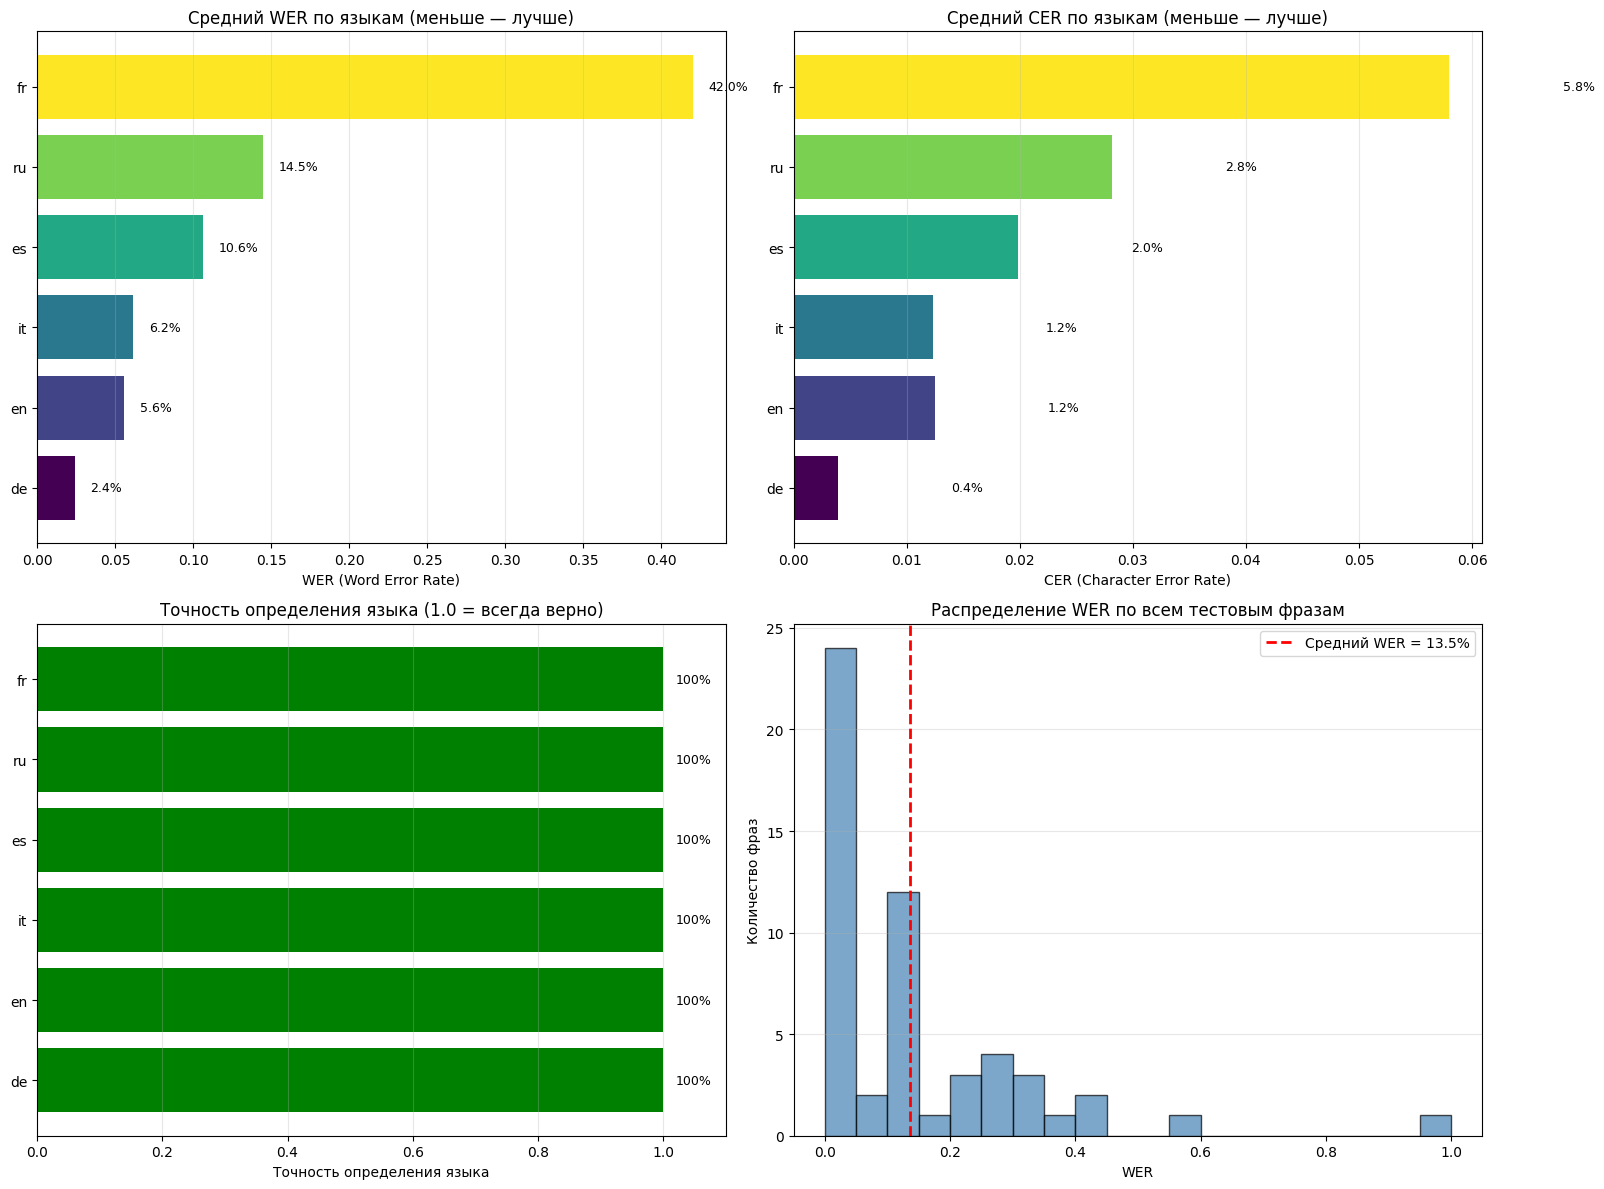

In [210]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


colors = plt.cm.viridis(np.linspace(0, 1, len(lang_stats)))
bars1 = axes[0, 0].barh(lang_stats["lang"], lang_stats["avg_wer"], color=colors)
axes[0, 0].set_xlabel("WER (Word Error Rate)")
axes[0, 0].set_title("Средний WER по языкам (меньше — лучше)")
axes[0, 0].grid(alpha=0.3, axis="x")
for bar, val in zip(bars1, lang_stats["avg_wer"]):
    axes[0, 0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                   f"{val:.1%}", va="center", fontsize=9)


bars2 = axes[0, 1].barh(lang_stats["lang"], lang_stats["avg_cer"], color=colors)
axes[0, 1].set_xlabel("CER (Character Error Rate)")
axes[0, 1].set_title("Средний CER по языкам (меньше — лучше)")
axes[0, 1].grid(alpha=0.3, axis="x")
for bar, val in zip(bars2, lang_stats["avg_cer"]):
    axes[0, 1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                   f"{val:.1%}", va="center", fontsize=9)


colors_lang = ["green" if acc == 1.0 else "orange" if acc >= 0.75 else "red"
               for acc in lang_stats["lang_accuracy"]]
bars3 = axes[1, 0].barh(lang_stats["lang"], lang_stats["lang_accuracy"], color=colors_lang)
axes[1, 0].set_xlabel("Точность определения языка")
axes[1, 0].set_title("Точность определения языка (1.0 = всегда верно)")
axes[1, 0].set_xlim(0, 1.1)
axes[1, 0].grid(alpha=0.3, axis="x")
for bar, val in zip(bars3, lang_stats["lang_accuracy"]):
    axes[1, 0].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                   f"{val:.0%}", va="center", fontsize=9)


axes[1, 1].hist(asr_metrics["wer"], bins=20, color="steelblue", edgecolor="black", alpha=0.7)
axes[1, 1].axvline(avg_wer, color="red", linestyle="--", linewidth=2,
                   label=f"Средний WER = {avg_wer:.1%}")
axes[1, 1].set_xlabel("WER")
axes[1, 1].set_ylabel("Количество фраз")
axes[1, 1].set_title("Распределение WER по всем тестовым фразам")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Этап 4: Перевод запроса на английский

In [72]:
!pip install -q transformers sentencepiece langdetect fasttext-langdetect torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.1/296.1 kB 28.4 MB/s eta 0:00:00


In [73]:
from transformers import MarianMTModel, MarianTokenizer
import torch
from typing import Dict, Tuple

LANGUAGE_TO_MODEL = {
    "ru": "Helsinki-NLP/opus-mt-ru-en",   # русский
    "de": "Helsinki-NLP/opus-mt-de-en",   # немецкий
    "fr": "Helsinki-NLP/opus-mt-fr-en",   # французский
    "es": "Helsinki-NLP/opus-mt-es-en",   # испанский
    "it": "Helsinki-NLP/opus-mt-it-en",   # итальянский
    "pt": "Helsinki-NLP/opus-mt-pt-en",   # португальский
    "nl": "Helsinki-NLP/opus-mt-nl-en",   # нидерландский
    "pl": "Helsinki-NLP/opus-mt-pl-en",   # польский
    "tr": "Helsinki-NLP/opus-mt-tr-en",   # турецкий
    "cs": "Helsinki-NLP/opus-mt-cs-en",   # чешский
    "sv": "Helsinki-NLP/opus-mt-sv-en",   # шведский
    "uk": "Helsinki-NLP/opus-mt-uk-en",   # украинский
    "zh": "Helsinki-NLP/opus-mt-zh-en",   # китайский
    "ja": "Helsinki-NLP/opus-mt-ja-en",   # японский
    "ko": "Helsinki-NLP/opus-mt-ko-en",   # корейский
    "ar": "Helsinki-NLP/opus-mt-ar-en",   # арабский
    "hi": "Helsinki-NLP/opus-mt-hi-en",   # хинди
    "el": "Helsinki-NLP/opus-mt-el-en",   # греческий
    "he": "Helsinki-NLP/opus-mt-he-en",   # иврит
}

translation_cache: Dict[str, Tuple[MarianMTModel, MarianTokenizer]] = {}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")
print(f"Поддерживается языков: {len(LANGUAGE_TO_MODEL)}")

Устройство: cuda
Поддерживается языков: 19


In [74]:
import time

def load_translation_model(src_lang: str) -> Tuple[MarianMTModel, MarianTokenizer]:

    if src_lang not in LANGUAGE_TO_MODEL:
        raise ValueError(f"Язык '{src_lang}' не поддерживается. "
                        f"Доступные: {list(LANGUAGE_TO_MODEL.keys())}")

    if src_lang in translation_cache:
        return translation_cache[src_lang]

    model_name = LANGUAGE_TO_MODEL[src_lang]
    print(f"  Загрузка модели перевода: {model_name}")
    t0 = time.time()

    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name).to(device)
    model.eval()

    elapsed = time.time() - t0
    print(f"  Модель загружена за {elapsed:.1f} сек")

    translation_cache[src_lang] = (model, tokenizer)
    return model, tokenizer

In [75]:
def translate_to_english(text: str, src_lang: str) -> str:

    if src_lang == "en":
        return text

    model, tokenizer = load_translation_model(src_lang)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(device)

    with torch.no_grad():
        translated = model.generate(
            **inputs,
            num_beams=4,
            max_length=512,
            early_stopping=True,
        )

    result = tokenizer.decode(
        translated[0],
        skip_special_tokens=True,
    )

    return result

In [76]:
TEST_TRANSLATIONS = [
    ("ru", "Где находится Эйфелева башня и как до неё добраться на метро?"),
    ("ru", "Подскажи хорошие рестораны с местной кухней в Берлине"),
    ("fr", "Où se trouve le musée du Louvre et quel est le prix d'entrée?"),
    ("fr", "Quels sont les meilleurs quartiers pour sortir le soir à Paris?")
]

for src_lang, original_text in TEST_TRANSLATIONS:
    print(f"\n[{src_lang.upper()}] Исходный: {original_text}")

    t0 = time.time()
    translated = translate_to_english(original_text, src_lang)
    elapsed = time.time() - t0

    print(f"[EN]  Перевод:  {translated}")
    print(f"      Время: {elapsed:.2f} сек")


[RU] Исходный: Где находится Эйфелева башня и как до неё добраться на метро?
  Загрузка модели перевода: Helsinki-NLP/opus-mt-ru-en


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

  Модель загружена за 10.7 сек
[EN]  Перевод:  Where is the Louvre Museum and what is the entry price?
      Время: 10.83 сек

[FR] Исходный: Quels sont les meilleurs quartiers pour sortir le soir à Paris?
[EN]  Перевод:  What are the best neighborhoods to go out in Paris at night?
      Время: 0.17 сек


In [77]:
from langdetect import detect, LangDetectException

def detect_language(text: str, whisper_lang: str = None) -> str:

    if whisper_lang and whisper_lang in LANGUAGE_TO_MODEL:
        return whisper_lang

    try:
        detected = detect(text)
        if detected in LANGUAGE_TO_MODEL:
            return detected
        return detected
    except LangDetectException:
        return "en"

In [78]:
def process_text_query(text: str, whisper_lang: str = None) -> dict:

    t0 = time.time()

    original_lang = detect_language(text, whisper_lang)

    was_translated = (original_lang != "en")
    if was_translated:
        english_text = translate_to_english(text, original_lang)
    else:
        english_text = text

    processing_time = time.time() - t0

    return {
        "original_text": text,
        "original_lang": original_lang,
        "english_text": english_text,
        "was_translated": was_translated,
        "processing_time_sec": processing_time,
    }

In [191]:
def process_audio_to_english_query(audio_path: str) -> dict:

    asr_result = transcribe_audio(audio_path)
    raw_text = asr_result["text"]
    whisper_lang = asr_result["language"]

    print(f"[ASR] Распознанный текст: {raw_text}")
    print(f"[ASR] Язык (Whisper): {whisper_lang}")

    query_result = process_text_query(raw_text, whisper_lang)

    if query_result["was_translated"]:
        print(f"[TRANSLATE] Перевод на английский: {query_result['english_text']}")
    else:
        print(f"[TRANSLATE] Уже на английском, перевод не нужен")

    return {
        "asr": asr_result,
        "query": query_result,
    }

In [192]:

audio_path = "/content/data/recorded_audio.webm"
result = process_audio_to_english_query(audio_path)


[ASR] Распознанный текст: Где поесть в Париже?
[ASR] Язык (Whisper): ru
[TRANSLATE] Перевод на английский: Where to eat in Paris?


In [221]:
translation_test_cases = [

    ("ru", "Расскажи про главные достопримечательности Рима",
     "Tell me about the main attractions of Rome"),
    ("ru", "Как добраться от аэропорта Фьюмичино до центра города?",
     "How to get from Fiumicino airport to the city center?"),
    ("ru", "Где можно вкусно пообедать рядом с Колизеем?",
     "Where can I have a good lunch near the Colosseum?"),
    ("ru", "Во сколько открывается Ватикан и сколько стоит билет?",
     "What time does the Vatican open and how much is the ticket?"),
    ("ru", "Подскажи недорогой отель в центре Барселоны",
     "Recommend an inexpensive hotel in the center of Barcelona"),
    ("ru", "Какие сувениры привезти из Праги?",
     "What souvenirs to bring from Prague?"),
    ("ru", "Как пройти к площади Навона от вокзала Термини?",
     "How to get to Piazza Navona from Termini station?"),
    ("ru", "Где ближайшая станция метро к Эйфелевой башне?",
     "Where is the nearest metro station to the Eiffel Tower?"),
    ("ru", "Какие музеи стоит посетить в Берлине?",
     "What museums are worth visiting in Berlin?"),


    ("en", "What are the must-see attractions in Paris?",
     "What are the must-see attractions in Paris?"),
    ("en", "How do I get from Heathrow airport to central London?",
     "How do I get from Heathrow airport to central London?"),
    ("en", "Can you recommend a good local restaurant near the Colosseum?",
     "Can you recommend a good local restaurant near the Colosseum?"),
    ("en", "What time does the Louvre Museum open and how much is the ticket?",
     "What time does the Louvre Museum open and how much is the ticket?"),
    ("en", "Where can I find budget accommodation in Amsterdam?",
     "Where can I find budget accommodation in Amsterdam?"),
    ("en", "What's the best way to get to the Eiffel Tower by public transport?",
     "What's the best way to get to the Eiffel Tower by public transport?"),
    ("en", "Are there any good shopping districts in Madrid?",
     "Are there any good shopping districts in Madrid?"),
    ("en", "How do I buy a ticket for the metro in Berlin?",
     "How do I buy a ticket for the metro in Berlin?"),
    ("en", "What are the opening hours of the Vatican Museums?",
     "What are the opening hours of the Vatican Museums?"),


    ("de", "Erzähl mir von den wichtigsten Sehenswürdigkeiten in Rom",
     "Tell me about the most important sights in Rome"),
    ("de", "Wie komme ich vom Flughafen zum Stadtzentrum?",
     "How do I get from the airport to the city center?"),
    ("de", "Wo kann ich in der Nähe des Eiffelturms gut essen gehen?",
     "Where can I eat well near the Eiffel Tower?"),
    ("de", "Wie viel kostet eine Fahrkarte für die Metro in Paris?",
     "How much does a metro ticket in Paris cost?"),
    ("de", "Welche Museen sollte man in Berlin unbedingt besuchen?",
     "Which museums should one definitely visit in Berlin?"),
    ("de", "Wo gibt es günstige Hotels im Zentrum von Barcelona?",
     "Where are there cheap hotels in the center of Barcelona?"),
    ("de", "Wie komme ich mit öffentlichen Verkehrsmitteln zum Kolosseum?",
     "How do I get to the Colosseum by public transport?"),
    ("de", "Was sind typische Souvenirs aus Prag?",
     "What are typical souvenirs from Prague?"),
    ("de", "Gibt es gute Restaurants in der Nähe des Louvre?",
     "Are there good restaurants near the Louvre?"),


    ("fr", "Parle-moi des principales attractions touristiques de Rome",
     "Tell me about the main tourist attractions of Rome"),
    ("fr", "Comment aller de l'aéroport au centre-ville?",
     "How to go from the airport to the city center?"),
    ("fr", "Où peut-on bien manger près de la Tour Eiffel?",
     "Where can one eat well near the Eiffel Tower?"),
    ("fr", "Quel est le prix d'un billet de métro à Berlin?",
     "What is the price of a metro ticket in Berlin?"),
    ("fr", "Quels musées faut-il absolument visiter à Prague?",
     "Which museums must one absolutely visit in Prague?"),
    ("fr", "Où trouver un hôtel pas cher dans le centre de Madrid?",
     "Where to find a cheap hotel in the center of Madrid?"),
    ("fr", "Comment me rendre au Colisée en transports en commun?",
     "How to get to the Colosseum by public transport?"),
    ("fr", "Quels souvenirs typiques acheter à Amsterdam?",
     "What typical souvenirs to buy in Amsterdam?"),
    ("fr", "Y a-t-il de bons restaurants près du Louvre?",
     "Are there good restaurants near the Louvre?"),


    ("es", "Cuéntame sobre los principales lugares turísticos de Roma",
     "Tell me about the main tourist places in Rome"),
    ("es", "¿Cómo llego desde el aeropuerto al centro de la ciudad?",
     "How do I get from the airport to the city center?"),
    ("es", "¿Dónde puedo comer bien cerca de la Torre Eiffel?",
     "Where can I eat well near the Eiffel Tower?"),
    ("es", "¿Cuánto cuesta un billete de metro en Berlín?",
     "How much does a metro ticket in Berlin cost?"),
    ("es", "¿Qué museos hay que visitar en Praga?",
     "What museums should one visit in Prague?"),
    ("es", "¿Dónde encontrar hoteles baratos en el centro de Ámsterdam?",
     "Where to find cheap hotels in the center of Amsterdam?"),
    ("es", "¿Cómo llego al Coliseo en transporte público?",
     "How do I get to the Colosseum by public transport?"),
    ("es", "¿Qué recuerdos típicos comprar en París?",
     "What typical souvenirs to buy in Paris?"),
    ("es", "¿Hay buenos restaurantes cerca del Louvre?",
     "Are there good restaurants near the Louvre?"),


    ("it", "Raccontami delle principali attrazioni turistiche di Parigi",
     "Tell me about the main tourist attractions of Paris"),
    ("it", "Come arrivo dall'aeroporto al centro città?",
     "How do I get from the airport to the city center?"),
    ("it", "Dove si può mangiare bene vicino alla Torre Eiffel?",
     "Where can one eat well near the Eiffel Tower?"),
    ("it", "Quanto costa un biglietto della metro a Berlino?",
     "How much does a metro ticket in Berlin cost?"),
    ("it", "Quali musei bisogna assolutamente visitare a Praga?",
     "Which museums must one absolutely visit in Prague?"),
    ("it", "Dove trovare hotel economici nel centro di Amsterdam?",
     "Where to find cheap hotels in the center of Amsterdam?"),
    ("it", "Come arrivo al Colosseo con i mezzi pubblici?",
     "How do I get to the Colosseum by public transport?"),
    ("it", "Quali souvenir tipici comprare a Madrid?",
     "What typical souvenirs to buy in Madrid?"),
    ("it", "Ci sono buoni ristoranti vicino al Louvre?",
     "Are there good restaurants near the Louvre?"),
]

print(f"Всего тестовых пар для перевода: {len(translation_test_cases)}")

from collections import Counter
lang_counts = Counter(lang for lang, _, _ in translation_test_cases)
print("\nРаспределение по языкам:")
for lang, count in sorted(lang_counts.items()):
    print(f"  {lang}: {count} фраз")

Всего тестовых пар для перевода: 54

Распределение по языкам:
  de: 9 фраз
  en: 9 фраз
  es: 9 фраз
  fr: 9 фраз
  it: 9 фраз
  ru: 9 фраз


In [194]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00


In [222]:
from jiwer import wer, cer
from sacrebleu.metrics import BLEU, CHRF
import numpy as np
import pandas as pd

bleu_scorer = BLEU()
chrf_scorer = CHRF()


translation_results = {
    "language": [],
    "phrase_idx": [],
    "reference": [],
    "asr_hypothesis": [],
    "translation_hypothesis": [],
    "bleu": [],
    "chrf": [],
    "asr_wer": [],
    "asr_cer": [],
}

for i, (lang, source_text, reference_en) in enumerate(translation_test_cases):
    audio_path = audio_paths[i]


    result = process_audio_to_english_query(audio_path)

    asr_text = result["asr"]["text"]
    translated_text = result["query"]["english_text"]


    b = bleu_scorer.corpus_score([translated_text], [[reference_en]]).score
    c = chrf_scorer.corpus_score([translated_text], [[reference_en]]).score


    w = wer(source_text, asr_text) if lang != "en" else 0.0
    cr = cer(source_text, asr_text) if lang != "en" else 0.0

    translation_results["language"].append(lang)
    translation_results["phrase_idx"].append(i)
    translation_results["reference"].append(reference_en)
    translation_results["asr_hypothesis"].append(asr_text)
    translation_results["translation_hypothesis"].append(translated_text)
    translation_results["bleu"].append(b)
    translation_results["chrf"].append(c)
    translation_results["asr_wer"].append(w)
    translation_results["asr_cer"].append(cr)

    print(f"\n[{i+1:2d}/{len(translation_test_cases)}] {lang.upper()}")
    print(f"  Эталон:     {reference_en}")
    print(f"  Перевод:    {translated_text}")
    print(f"  BLEU: {b:.2f} | chrF: {c:.2f}")

[ASR] Распознанный текст: Расскажи про главные достопримечательности Рима.
[ASR] Язык (Whisper): ru
[TRANSLATE] Перевод на английский: Tell me about Rome's main sights.

[ 1/54] RU
  Эталон:     Tell me about the main attractions of Rome
  Перевод:    Tell me about Rome's main sights.
  BLEU: 22.77 | chrF: 39.84
[ASR] Распознанный текст: Как добраться от аэропорта Фьюмичина до центра города?
[ASR] Язык (Whisper): ru
[TRANSLATE] Перевод на английский: How do you get from Fumichin airport to downtown?

[ 2/54] RU
  Эталон:     How to get from Fiumicino airport to the city center?
  Перевод:    How do you get from Fumichin airport to downtown?
  BLEU: 11.88 | chrF: 39.95
[ASR] Распознанный текст: Где можно вкусно пообедать рядом с колезеем?
[ASR] Язык (Whisper): ru
[TRANSLATE] Перевод на английский: Where can you have a nice lunch next to a goat?

[ 3/54] RU
  Эталон:     Where can I have a good lunch near the Colosseum?
  Перевод:    Where can you have a nice lunch next to a goat?
  BLEU

In [223]:
df_transl = pd.DataFrame(translation_results)


lang_transl_stats = df_transl.groupby("language").agg(
    n_phrases=("bleu", "count"),
    avg_bleu=("bleu", "mean"),
    avg_chrf=("chrf", "mean"),
    avg_asr_wer=("asr_wer", "mean"),
    avg_asr_cer=("asr_cer", "mean"),
).reset_index()

lang_transl_stats = lang_transl_stats.sort_values("avg_bleu", ascending=False)


print(lang_transl_stats.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


print(f"  средний BLEU: {df_transl['bleu'].mean():.2f}")
print(f"  средний chrF: {df_transl['chrf'].mean():.2f}")
print(f"  Средний WER распознавания: {df_transl[df_transl['language'] != 'en']['asr_wer'].mean():.1%}")

language  n_phrases  avg_bleu  avg_chrf  avg_asr_wer  avg_asr_cer
      en          9    87.326    94.901        0.000        0.000
      de          9    79.063    90.107        0.024        0.004
      it          9    61.211    80.340        0.062        0.012
      es          9    57.181    76.944        0.106        0.020
      fr          9    51.869    73.050        0.420        0.058
      ru          9    21.916    50.218        0.145        0.028
  средний BLEU: 59.76
  средний chrF: 77.59
  Средний WER распознавания: 15.1%


In [225]:
df_transl["error_impact"] = df_transl["asr_wer"] * (100 - df_transl["bleu"]) / 100

worst_cascade = df_transl.nlargest(5, "error_impact")

print("\nсильное влияние ошибок ASR на перевод:")
for _, row in worst_cascade.iterrows():
    print(f"\n  [{row['language'].upper()}]")
    print(f"    Исходная фраза:    {translation_test_cases[row['phrase_idx']][1]}")
    print(f"    Распознано (ASR):  {row['asr_hypothesis']}")
    print(f"    Эталон перевода:   {row['reference']}")
    print(f"    Перевод:           {row['translation_hypothesis']}")
    print(f"    WER ASR: {row['asr_wer']:.1%} | BLEU: {row['bleu']:.1f}")

best_cascade = df_transl[df_transl["language"] != "en"].nsmallest(5, "error_impact")

print("\nминимальное влияние ошибок ASR")
for _, row in best_cascade.iterrows():
    print(f"\n  [{row['language'].upper()}]")
    print(f"    Распознано:  {row['asr_hypothesis']}")
    print(f"    Перевод:     {row['translation_hypothesis']}")
    print(f"    Эталон:      {row['reference']}")
    print(f"    WER ASR: {row['asr_wer']:.1%} | BLEU: {row['bleu']:.1f}")


сильное влияние ошибок ASR на перевод:

  [FR]
    Исходная фраза:    Quels souvenirs typiques acheter à Amsterdam?
    Распознано (ASR):  Quel souvenir typique acheté à Amsterdam ?
    Эталон перевода:   What typical souvenirs to buy in Amsterdam?
    Перевод:           What typical memory bought in Amsterdam?
    WER ASR: 100.0% | BLEU: 26.6

  [FR]
    Исходная фраза:    Quels musées faut-il absolument visiter à Prague?
    Распознано (ASR):  Quel musée faut-il absolument visiter à Prague ?
    Эталон перевода:   Which museums must one absolutely visit in Prague?
    Перевод:           Which museum should you visit in Prague?
    WER ASR: 57.1% | BLEU: 32.3

  [RU]
    Исходная фраза:    Какие сувениры привезти из Праги?
    Распознано (ASR):  Какие сувениры привести из праги?
    Эталон перевода:   What souvenirs to bring from Prague?
    Перевод:           What kind of souvenirs do you want me to bring out?
    WER ASR: 40.0% | BLEU: 8.5

  [FR]
    Исходная фраза:    Comment me 

# Этап 5: RAG-генерация ответа

In [93]:
import os
import json
from google.colab import drive
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
import torch


drive.mount('/content/drive')


DRIVE_PROJECT_DIR = "/content/drive/MyDrive/wikivoyage_rag_project"
CHROMA_DIR = os.path.join(DRIVE_PROJECT_DIR, "chroma_wikivoyage_v2")


config_path = os.path.join(DRIVE_PROJECT_DIR, "vector_db_config.json")
with open(config_path, "r") as f:
    db_config = json.load(f)

print("Конфигурация базы:")
print(json.dumps(db_config, indent=2))


device = "cuda" if torch.cuda.is_available() else "cpu"
embeddings_model = HuggingFaceEmbeddings(
    model_name=db_config["embedding_model"],
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True, "batch_size": 128},
)


vectorstore = Chroma(
    collection_name=db_config["collection_name"],
    embedding_function=embeddings_model,
    persist_directory=CHROMA_DIR,
)

print(f"\nВекторная база загружена: {vectorstore._collection.count()} чанков")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Конфигурация базы:
{
  "vector_db_type": "chroma",
  "chroma_dir": "/content/data/chroma_wikivoyage_v2",
  "collection_name": "wikivoyage_v2",
  "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
  "splitter": "Recursive",
  "chunk_size": 500,
  "chunk_overlap": 100,
  "n_chunks": 153762,
  "n_source_sections": 86326,
  "n_articles": 19507
}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Векторная база загружена: 153762 чанков


In [98]:
def retrieve_context(english_query: str, k: int = 5) -> list:
    """
    Ищет top-K релевантных чанков по английскому запросу.

    Возвращает список словарей с метаданными и текстом.
    """
    docs = vectorstore.similarity_search_with_score(english_query, k=k)

    results = []
    for doc, score in docs:
        results.append({
            "title": doc.metadata.get("title", "unknown"),
            "section": doc.metadata.get("section", "unknown"),
            "score": float(score),
            "text": doc.page_content,
        })

    return results


english_query = result["query"]["english_text"]
print(f"\nПоиск по запросу: '{english_query}'")
print("="*70)

retrieved = retrieve_context(english_query, k=5)

for i, r in enumerate(retrieved, 1):
    print(f"\n[{i}] {r['title']} / {r['section']} (score: {r['score']:.3f})")
    print(f"    {r['text'][:200]}...")


Поиск по запросу: 'Where to eat in Paris?'

[1] Paris / food (score: 0.485)
    . For an easy-to-manage eating budget while in Paris, consider: breakfast or "petit déjeuner" at a restaurant, possibly in your hotel, consisting of some croissants, coffee, and maybe a piece of fruit...

[2] Paris / food (score: 0.537)
    . For dinner, stroll the streets at dusk and consider a €20-40 prix-fixe menu. This will get you 3 or 4 courses, possibly with wine, and an unhurried, candlelit, magical evening. If you alternate days...

[3] Paris / food (score: 0.586)
    . Of course there are also some traditional offerings, and for the budget conscious there are hundreds of traditional bistros, with their sidewalk terraces offering a choice of fairly simple (usually ...

[4] Paris/17th arrondissement / food (score: 0.633)
    Though the diversity of cuisine is definitely a notch below the rest of Paris, the 17th arrondissement represents probably the best opportunity to experience true Parisian and 

In [99]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

LLM_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"\nЗагрузка LLM: {LLM_MODEL}...")

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,
    low_cpu_mem_usage=True,
)

llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=300,
    do_sample=False,
    repetition_penalty=1.2,
    return_full_text=False,
    pad_token_id=tokenizer.eos_token_id,
)

print("LLM загружена")


Загрузка LLM: Qwen/Qwen2.5-1.5B-Instruct...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'repetition_penalty', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


LLM загружена


In [100]:
def generate_answer(
    original_question: str,
    original_lang: str,
    context_chunks: list,
) -> str:
    """
    Генерирует ответ на языке пользователя на основе найденного контекста.
    """

    context_text = "\n\n---\n\n".join([
        f"[{c['title']} / {c['section']}]:\n{c['text']}"
        for c in context_chunks
    ])

    lang_names = {
        "ru": "Russian", "en": "English", "de": "German", "fr": "French",
        "es": "Spanish", "it": "Italian", "pt": "Portuguese", "pl": "Polish",
        "tr": "Turkish", "cs": "Czech", "sv": "Swedish", "uk": "Ukrainian",
        "zh": "Chinese", "ja": "Japanese", "ko": "Korean", "ar": "Arabic",
        "hi": "Hindi", "el": "Greek", "he": "Hebrew", "nl": "Dutch",
    }
    target_lang = lang_names.get(original_lang, "English")

    messages = [
        {
            "role": "system",
            "content": (
                f"You are a helpful multilingual tourist assistant. "
                f"Answer the user's question using ONLY the provided context from Wikivoyage. "
                f"You MUST respond in {target_lang} language.\n\n"
                f"Rules:\n"
                f"1. If the answer is not in the context, say: 'I do not have this information in my knowledge base.'\n"
                f"2. Do not use external knowledge.\n"
                f"3. Be concise but informative (2-5 sentences).\n"
                f"4. Quote specific facts (names, addresses, prices) exactly.\n"
                f"5. If multiple chunks contain relevant info, synthesize them coherently."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Retrieved context from Wikivoyage:\n\n{context_text}\n\n"
                f"User question (in {target_lang}): {original_question}"
            ),
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    output = llm_pipeline(prompt)
    return output[0]["generated_text"].strip()

In [228]:
def rag_pipeline(audio_result: dict, k: int = 3, verbose: bool = True) -> dict:

    english_query = audio_result["query"]["english_text"]
    original_question = audio_result["query"]["original_text"]
    original_lang = audio_result["query"]["original_lang"]

    if verbose:
        print(f"\nПоиск в базе по запросу: '{english_query}'")

    retrieved = retrieve_context(english_query, k=k)

    if verbose:
        print(f"   Найдено чанков: {len(retrieved)}")
        for i, r in enumerate(retrieved[:3], 1):
            print(f"   {i}. {r['title']} / {r['section']}")

    if verbose:
        print(f"\nГенерация ответа на языке: {original_lang}")

    answer = generate_answer(original_question, original_lang, retrieved)

    if verbose:
        print(f"\nОТВЕТ:")
        print(f"   {answer}")

    return {
        "audio_result": audio_result,
        "retrieved_chunks": retrieved,
        "answer": answer,
        "language": original_lang,
    }

In [105]:
final_result = rag_pipeline(result, k=3, verbose=True)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Поиск в базе по запросу: 'Where to eat in Paris?'
   Найдено чанков: 3
   1. Paris / food
   2. Paris / food
   3. Paris / food

Генерация ответа на языке: ru

ОТВЕТ:
   В Париже есть множество вариантов для обеда и ужина на любой вкус и бюджет. Для экономии можно попробовать завтрак или «петит де шеј» в ресторанах рядом с отелем, где предлагают блины, кофе и фрукты. Также стоит воспользоваться местными стойлами за панино в центре города, кревепы из картофеля или творожные пиццы в Мариссе. Если вы хотите провести вечер без лишних затрат, то можно заказать меню приготовленное заранее — это позволит вам получить небольшое количество блюд под разнообразием ценовой категории. Важным моментом является выбор места питания, так как цены могут сильно различаться даже внутри одного района.


In [230]:
TEST_QUESTIONS = [

    {
        "question": "What is the Colosseum in Rome?",
        "type": "local_fact",
        "description": "Простой факт о конкретной достопримечательности",
    },
    {
        "question": "How much does a metro ticket cost in Paris?",
        "type": "local_fact",
        "description": "Конкретная цена билета",
    },


    {
        "question": "What are the main attractions in Rome?",
        "type": "aggregating",
        "description": "Нужно собрать информацию из нескольких чанков про Рим",
    },
    {
        "question": "What traditional food should I try in Tokyo?",
        "type": "aggregating",
        "description": "Нужна агрегация информации о еде из разных чанков",
    },


    {
        "question": "How to get from Charles de Gaulle airport to Paris center?",
        "type": "transport",
        "description": "Информация о транспорте из аэропорта",
    },
    {
        "question": "How to get around Amsterdam using public transport?",
        "type": "transport",
        "description": "Общая информация о транспорте в городе",
    },


    {
        "question": "Compare the nightlife in Berlin and Barcelona",
        "type": "comparison",
        "description": "Нужно сравнить информацию из двух разных городов",
    },


    {
        "question": "What is the history of the Vatican?",
        "type": "cultural",
        "description": "Исторический контекст",
    },

    {
        "question": "Tell me about the pyramids on Mars",
        "type": "out_of_scope",
        "description": "Абсурдный вопрос, которого точно нет в базе",
    },
]

print(f"Составлено {len(TEST_QUESTIONS)} тестовых вопросов:")
print("\nРаспределение по типам:")
from collections import Counter
type_counts = Counter(q["type"] for q in TEST_QUESTIONS)
for qtype, count in type_counts.items():
    print(f"  {qtype:20s}: {count}")

Составлено 9 тестовых вопросов:

Распределение по типам:
  local_fact          : 2
  aggregating         : 2
  transport           : 2
  comparison          : 1
  cultural            : 1
  out_of_scope        : 1


In [231]:
def analyze_question_with_different_k(question: str, k_values=[1, 3, 5, 10], verbose=True):
    """
    Анализирует вопрос при разных значениях k.
    Показывает найденные чанки и сгенерированные ответы.
    """

    print(f"Вопрос: {question}")
    print(f"{'='*80}")

    for k in k_values:

        print(f"{'─'*80}")


        retrieved = retrieve_context(question, k=k)


        print(f"\nЧанки ({len(retrieved)}):")
        for i, r in enumerate(retrieved, 1):
            print(f"\n  [{i}] {r['title']} / {r['section']} (score: {r['score']:.3f})")
            print(f"      {r['text'][:200]}...")


        answer = generate_answer(question, "en", retrieved)

        print(f"\nОтвет модели:")
        print(f"  {answer}")
        print()

In [233]:
k_values = [1, 3, 5, 10]

for i, q in enumerate(TEST_QUESTIONS, 1):

    analyze_question_with_different_k(
        question=q["question"],
        k_values=k_values,
        verbose=True
    )

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What is the Colosseum in Rome?
────────────────────────────────────────────────────────────────────────────────

Чанки (1):

  [1] Constantine / nearby (score: 0.685)
      , a Roman city and one of the most important archaeological sites in the region....


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Ответ модели:
  The Colosseum, also known as the Flavian Amphitheatre, was an enormous amphitheater built during the reigns of Emperor Vespasian and his son Titus between 70–80 AD. It served various functions including gladiatorial contests and public spectacles such as mock sea battles, animal hunts, executions, reenactments of famous battles, and dramas based on Classical mythology. The structure stands today approximately 69 meters high with its outer walls measuring about 189 meters long and 156 wide at their widest points. Its construction involved over 10,000 workers who worked for around three years to complete it. Today, visitors can explore parts of the site that were excavated since the early 19th century when archaeologists began systematically uncovering layers beneath what had been thought to be solid ground.

────────────────────────────────────────────────────────────────────────────────

Чанки (3):

  [1] Constantine / nearby (score: 0.685)
      , a Roman city and one

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


Ответ модели:
  I do not have this information in my knowledge base.

────────────────────────────────────────────────────────────────────────────────

Чанки (3):

  [1] Shingo / sights (score: 0.759)
      The Pyramids are a mildly disappointing site with a spectacular view. The pyramids themselves are a very short hike uphill from a dirt road. They consist of a few large boulders on top of the hill. No...

  [2] Abusir / nearby (score: 0.862)
      Cairo Memphis Saqqara — an extensive number of pyramids and tombs on a plateau above the Nile Valley, just a few km South from Abusir...

  [3] Cairo/Giza / understand (score: 0.897)
      . A low ridge cuts the view to the south & west so it feels like the threshold of the Sahara, not just a sandy park or anti-oasis in the midst of burbs and more burbs. To the southeast, the pyramids o...


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Ответ модели:
  I do not have this information in my knowledge base.

────────────────────────────────────────────────────────────────────────────────

Чанки (5):

  [1] Shingo / sights (score: 0.759)
      The Pyramids are a mildly disappointing site with a spectacular view. The pyramids themselves are a very short hike uphill from a dirt road. They consist of a few large boulders on top of the hill. No...

  [2] Abusir / nearby (score: 0.862)
      Cairo Memphis Saqqara — an extensive number of pyramids and tombs on a plateau above the Nile Valley, just a few km South from Abusir...

  [3] Cairo/Giza / understand (score: 0.897)
      . A low ridge cuts the view to the south & west so it feels like the threshold of the Sahara, not just a sandy park or anti-oasis in the midst of burbs and more burbs. To the southeast, the pyramids o...

  [4] Abusir / sights (score: 0.934)
      The Abusir necropolis is open daily 8am-4pm. Admission LE80 (as of Dec 2018). 14 pyramids were constructed 

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Ответ модели:
  I do not have this information in my knowledge base.

────────────────────────────────────────────────────────────────────────────────

Чанки (10):

  [1] Shingo / sights (score: 0.759)
      The Pyramids are a mildly disappointing site with a spectacular view. The pyramids themselves are a very short hike uphill from a dirt road. They consist of a few large boulders on top of the hill. No...

  [2] Abusir / nearby (score: 0.862)
      Cairo Memphis Saqqara — an extensive number of pyramids and tombs on a plateau above the Nile Valley, just a few km South from Abusir...

  [3] Cairo/Giza / understand (score: 0.897)
      . A low ridge cuts the view to the south & west so it feels like the threshold of the Sahara, not just a sandy park or anti-oasis in the midst of burbs and more burbs. To the southeast, the pyramids o...

  [4] Abusir / sights (score: 0.934)
      The Abusir necropolis is open daily 8am-4pm. Admission LE80 (as of Dec 2018). 14 pyramids were constructed


Среднее количество уникальных источников по k:
  k= 1: 1.0 уникальных статей
  k= 3: 3.0 уникальных статей
  k= 5: 4.8 уникальных статей
  k=10: 9.2 уникальных статей


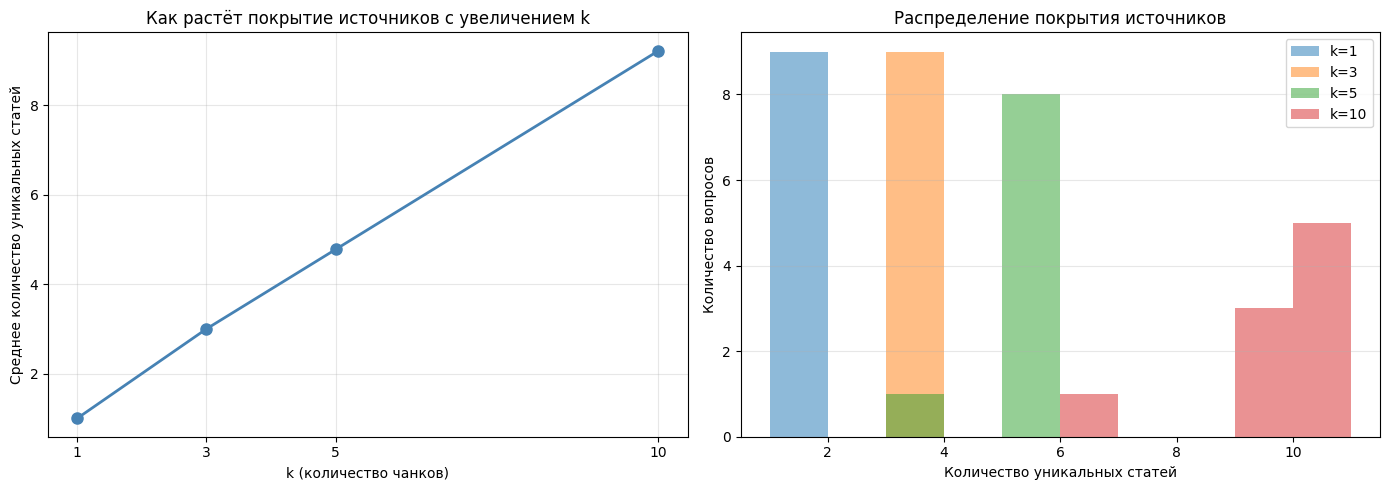

In [234]:
import matplotlib.pyplot as plt


unique_sources_by_k = {k: [] for k in k_values}

for q in TEST_QUESTIONS:
    for k in k_values:
        retrieved = retrieve_context(q["question"], k=k)
        unique_sources = len(set([r['title'] for r in retrieved]))
        unique_sources_by_k[k].append(unique_sources)


avg_unique_sources = {k: np.mean(unique_sources_by_k[k]) for k in k_values}

print("\nСреднее количество уникальных источников по k:")
for k, avg in avg_unique_sources.items():
    print(f"  k={k:2d}: {avg:.1f} уникальных статей")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(list(avg_unique_sources.keys()), list(avg_unique_sources.values()),
             marker="o", linewidth=2, markersize=8, color="steelblue")
axes[0].set_xlabel("k (количество чанков)")
axes[0].set_ylabel("Среднее количество уникальных статей")
axes[0].set_title("Как растёт покрытие источников с увеличением k")
axes[0].grid(alpha=0.3)
axes[0].set_xticks(k_values)


for k in k_values:
    axes[1].hist(unique_sources_by_k[k], bins=range(1, 12), alpha=0.5, label=f"k={k}")
axes[1].set_xlabel("Количество уникальных статей")
axes[1].set_ylabel("Количество вопросов")
axes[1].set_title("Распределение покрытия источников")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Синтез речи

In [126]:
!pip install -q edge-tts

In [128]:
!pip install -q nest_asyncio

In [129]:
import nest_asyncio
nest_asyncio.apply()

import edge_tts
import asyncio
import pandas as pd

async def list_voices():
    voices = await edge_tts.list_voices()
    return voices

voices = asyncio.run(list_voices())
df_voices = pd.DataFrame(voices)

print(f"Всего доступных голосов: {len(df_voices)}")
print(f"Языков: {df_voices['Locale'].nunique()}")

Всего доступных голосов: 322
Языков: 142


In [130]:
import edge_tts
import asyncio
import pandas as pd

async def list_voices():
    voices = await edge_tts.list_voices()
    return voices

voices = asyncio.run(list_voices())
df_voices = pd.DataFrame(voices)

print(f"Всего доступных голосов: {len(df_voices)}")
print(f"Языков: {df_voices['Locale'].nunique()}")
print(f"\nПримеры голосов для наших языков:")


PROJECT_LANGS = ["ru-RU", "en-US", "de-DE", "fr-FR", "es-ES", "it-IT",
                 "pt-PT", "pl-PL", "tr-TR", "cs-CZ", "zh-CN", "ja-JP",
                 "ko-KR", "ar-SA", "nl-NL", "uk-UA"]

for locale in PROJECT_LANGS:
    locale_voices = df_voices[df_voices["Locale"] == locale]
    if len(locale_voices) > 0:
        female = locale_voices[locale_voices["Gender"] == "Female"]
        chosen = female.iloc[0] if len(female) > 0 else locale_voices.iloc[0]
        print(f"  {locale:6s} → {chosen['ShortName']:35s} ({chosen['Gender']})")

Всего доступных голосов: 322
Языков: 142

Примеры голосов для наших языков:
  ru-RU  → ru-RU-SvetlanaNeural                (Female)
  en-US  → en-US-AvaNeural                     (Female)
  de-DE  → de-DE-SeraphinaMultilingualNeural   (Female)
  fr-FR  → fr-FR-VivienneMultilingualNeural    (Female)
  es-ES  → es-ES-XimenaNeural                  (Female)
  it-IT  → it-IT-ElsaNeural                    (Female)
  pt-PT  → pt-PT-RaquelNeural                  (Female)
  pl-PL  → pl-PL-ZofiaNeural                   (Female)
  tr-TR  → tr-TR-EmelNeural                    (Female)
  cs-CZ  → cs-CZ-VlastaNeural                  (Female)
  zh-CN  → zh-CN-XiaoxiaoNeural                (Female)
  ja-JP  → ja-JP-NanamiNeural                  (Female)
  ko-KR  → ko-KR-SunHiNeural                   (Female)
  ar-SA  → ar-SA-ZariyahNeural                 (Female)
  nl-NL  → nl-NL-ColetteNeural                 (Female)
  uk-UA  → uk-UA-PolinaNeural                  (Female)


In [132]:
VOICE_BY_LANG = {
    "ru": "ru-RU-SvetlanaNeural",
    "en": "en-US-JennyNeural",
    "de": "de-DE-KatjaNeural",
    "fr": "fr-FR-DeniseNeural",
    "es": "es-ES-ElviraNeural",
    "it": "it-IT-ElsaNeural",
    "pt": "pt-PT-RaquelNeural",
    "pl": "pl-PL-AgnieszkaNeural",
    "tr": "tr-TR-EmelNeural",
    "cs": "cs-CZ-VlastaNeural",
    "zh": "zh-CN-XiaoxiaoNeural",
    "ja": "ja-JP-NanamiNeural",
    "ko": "ko-KR-SunHiNeural",
    "ar": "ar-SA-ZariyahNeural",
    "nl": "nl-NL-ColetteNeural",
    "uk": "uk-UA-PolinaNeural",
    "el": "el-GR-AthinaNeural",
    "he": "he-IL-HilaNeural",
    "hi": "hi-IN-SwaraNeural",
    "sv": "sv-SE-SofieNeural",
}

print(f"Настроено голосов: {len(VOICE_BY_LANG)}")

Настроено голосов: 20


In [131]:
import os
import time
import edge_tts
import asyncio

async def _synthesize(text: str, voice: str, output_path: str, rate: str = "+0%", volume: str = "+0%"):

    communicate = edge_tts.Communicate(text, voice, rate=rate, volume=volume)
    await communicate.save(output_path)

def text_to_speech(
    text: str,
    lang: str,
    output_path: str = None,
    rate: str = "+0%",
    volume: str = "+0%",
) -> str:

    voice = VOICE_BY_LANG.get(lang)
    if voice is None:
        print(f"Голос для языка '{lang}' не найден, используем английский")
        voice = VOICE_BY_LANG["en"]


    if output_path is None:
        output_dir = "/content/data/tts_output"
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f"response_{lang}_{int(time.time())}.mp3")


    t0 = time.time()
    asyncio.run(_synthesize(text, voice, output_path, rate=rate, volume=volume))
    elapsed = time.time() - t0

    file_size = os.path.getsize(output_path) / 1024
    print(f"  TTS готов за {elapsed:.2f} сек")
    print(f"  Голос: {voice}")
    print(f"  Файл: {output_path} ({file_size:.1f} KB)")
    print(f"  Длина текста: {len(text)} символов")

    return output_path

In [235]:
from gtts import gTTS
from IPython.display import Audio, display

test_text = "Бранденбургские ворота — одна из главных достопримечательностей Берлина. Они расположены на площади Парижер Плац в центре города."


print("Сравнение: gTTS vs Edge TTS")


print("\n[1] gTTS (Google Text-to-Speech):")
gtts_path = "/content/data/tts_comparison_gtts.mp3"
t0 = time.time()
gTTS(text=test_text, lang="ru").save(gtts_path)
print(f"   Время: {time.time() - t0:.2f} сек, размер: {os.path.getsize(gtts_path)/1024:.1f} KB")
display(Audio(gtts_path, autoplay=False))

print("\n[2] Edge TTS (Microsoft, голос SvetlanaNeural):")
edge_path = "/content/data/tts_comparison_edge.mp3"
edge_tts_path = text_to_speech(test_text, "ru", output_path=edge_path)
display(Audio(edge_tts_path, autoplay=False))


Сравнение: gTTS vs Edge TTS

[1] gTTS (Google Text-to-Speech):
   Время: 0.48 сек, размер: 86.6 KB



[2] Edge TTS (Microsoft, голос SvetlanaNeural):
✓ TTS готов за 0.89 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/tts_comparison_edge.mp3 (55.4 KB)
  Длина текста: 129 символов


In [149]:
test_phrases = [
    ("ru", "Расскажи про Колизей."),
    ("en", "The Brandenburg Gate is located in the center of Berlin, near Pariser Platz."),
    ("de", "Das Brandenburger Tor befindet sich im Zentrum von Berlin, nahe dem Pariser Platz."),
    ("fr", "La porte de Brandebourg est situee au centre de Berlin, pres de la Pariser Platz."),
    ("es", "La Puerta de Brandeburgo se encuentra en el centro de Berlin, cerca de la Pariser Platz."),
    ("it", "La Porta di Brandeburgo si trova nel centro di Berlino, vicino a Pariser Platz."),
    ("zh", "勃兰登堡门位于柏林市中心,靠近巴黎广场."),
    ("ja", "ブランデンブルク門はベルリン中心部、パリザー広場の近くにあります."),
]

for lang, text in test_phrases:
    print(f"\n--- {lang.upper()} ({VOICE_BY_LANG.get(lang, 'N/A')}) ---")
    print(f"Текст: {text}")

    audio_path = text_to_speech(text, lang)
    display(Audio(audio_path, autoplay=False))


--- RU (ru-RU-SvetlanaNeural) ---
Текст: Расскажи про Колизей.
✓ TTS готов за 1.22 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/tts_output/response_ru_1782490935.mp3 (14.9 KB)
  Длина текста: 21 символов



--- EN (en-US-JennyNeural) ---
Текст: The Brandenburg Gate is located in the center of Berlin, near Pariser Platz.
✓ TTS готов за 0.72 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/tts_output/response_en_1782490936.mp3 (30.7 KB)
  Длина текста: 76 символов



--- DE (de-DE-KatjaNeural) ---
Текст: Das Brandenburger Tor befindet sich im Zentrum von Berlin, nahe dem Pariser Platz.
✓ TTS готов за 0.79 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/tts_output/response_de_1782490937.mp3 (36.1 KB)
  Длина текста: 82 символов



--- FR (fr-FR-DeniseNeural) ---
Текст: La porte de Brandebourg est situee au centre de Berlin, pres de la Pariser Platz.
✓ TTS готов за 0.79 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/tts_output/response_fr_1782490938.mp3 (31.4 KB)
  Длина текста: 81 символов



--- ES (es-ES-ElviraNeural) ---
Текст: La Puerta de Brandeburgo se encuentra en el centro de Berlin, cerca de la Pariser Platz.
✓ TTS готов за 0.79 сек
  Голос: es-ES-ElviraNeural
  Файл: /content/data/tts_output/response_es_1782490938.mp3 (31.5 KB)
  Длина текста: 88 символов



--- IT (it-IT-ElsaNeural) ---
Текст: La Porta di Brandeburgo si trova nel centro di Berlino, vicino a Pariser Platz.
✓ TTS готов за 0.80 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/tts_output/response_it_1782490939.mp3 (31.1 KB)
  Длина текста: 79 символов



--- ZH (zh-CN-XiaoxiaoNeural) ---
Текст: 勃兰登堡门位于柏林市中心,靠近巴黎广场.
✓ TTS готов за 0.74 сек
  Голос: zh-CN-XiaoxiaoNeural
  Файл: /content/data/tts_output/response_zh_1782490940.mp3 (27.4 KB)
  Длина текста: 20 символов



--- JA (ja-JP-NanamiNeural) ---
Текст: ブランデンブルク門はベルリン中心部、パリザー広場の近くにあります.
✓ TTS готов за 1.99 сек
  Голос: ja-JP-NanamiNeural
  Файл: /content/data/tts_output/response_ja_1782490941.mp3 (35.6 KB)
  Длина текста: 33 символов


In [140]:
def full_pipeline_with_tts(audio_path: str, k: int = 5, verbose: bool = True) -> dict:
    """
    Полный пайплайн:
    Аудио -> ASR -> Перевод -> Поиск в базе -> RAG-генерация -> TTS (Edge)
    """
    total_start = time.time()

    audio_result = process_audio_to_english_query(audio_path)
    original_lang = audio_result["query"]["original_lang"]
    original_text = audio_result["query"]["original_text"]
    english_query = audio_result["query"]["english_text"]


    retrieved = retrieve_context(english_query, k=k)
    if verbose:
        print(f"Найдено чанков: {len(retrieved)}")
        for i, r in enumerate(retrieved[:3], 1):
            print(f"  {i}. {r['title']} / {r['section']} (score: {r['score']:.3f})")


    answer = generate_answer(original_text, original_lang, retrieved)
    if verbose:
        print(f"Ответ (на языке {original_lang}):")
        print(f"  {answer}")


    tts_path = text_to_speech(answer, original_lang, rate="+5%")

    total_time = time.time() - total_start

    result = {
        "audio_input": audio_path,
        "asr": audio_result["asr"],
        "query": audio_result["query"],
        "retrieved_chunks": retrieved,
        "answer_text": answer,
        "answer_lang": original_lang,
        "tts_path": tts_path,
        "tts_voice": VOICE_BY_LANG.get(original_lang, "unknown"),
        "total_time_sec": total_time,
    }


    return result

In [236]:
audio_path = "/content/data/recorded_audio.webm"

if os.path.exists(audio_path):
    print(f"\nВходное аудио: {audio_path}")
    display(Audio(audio_path, autoplay=False))

    final_result = full_pipeline_with_tts(audio_path, k=5, verbose=True)


    print(f"Исходный вопрос: {final_result['query']['original_text']}")
    print(f"Язык: {final_result['answer_lang']}")
    print(f"Перевод на английский: {final_result['query']['english_text']}")
    print(f"\nНайденные источники:")
    for i, r in enumerate(final_result['retrieved_chunks'][:3], 1):
        print(f"  {i}. {r['title']} / {r['section']}")
    print(f"\nОтвет ассистента:")
    print(f"  {final_result['answer_text']}")

    print(f"\nОзвученный ответ:")
    display(Audio(final_result['tts_path'], autoplay=False))

else:
    print(f"Файл {audio_path} не найден. Сначала запишите аудио на Этапе 3.")


Входное аудио: /content/data/recorded_audio.webm


[ASR] Распознанный текст: Где поесть Парижа?
[ASR] Язык (Whisper): ru


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[TRANSLATE] Перевод на английский: Where to eat Paris?
Найдено чанков: 5
  1. Paris / food (score: 0.530)
  2. Paris / food (score: 0.560)
  3. Paris / food (score: 0.628)
Ответ (на языке ru):
  В Париже есть множество вариантов для питания, включая рестораны на улицах и барбекю с фриттатами. Например, можно попробовать панино из центра города или кревепицу от стендапа. Для более бюджетного выбора рекомендуется выбрать одно из многочисленных местной еды - например, бургеры в Марисе или хлебные лавки в Нормандии. Также стоит отметить, что многие рестораны высокого уровня расположены в пригородных деревнях, а не в крупных городах. В Лyonе особенно выделяются рестораны классического французского меню.
✓ TTS готов за 8.70 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/tts_output/response_ru_1782497745.mp3 (189.1 KB)
  Длина текста: 512 символов
Исходный вопрос: Где поесть Парижа?
Язык: ru
Перевод на английский: Where to eat Paris?

Найденные источники:
  1. Paris / food
  2. Paris

# Реализация диалога

In [142]:
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import time
import json

@dataclass
class Message:
    role: str
    content: str
    lang: str = "en"
    timestamp: float = field(default_factory=time.time)
    metadata: Dict = field(default_factory=dict)

    def to_dict(self):
        return {
            "role": self.role,
            "content": self.content,
            "lang": self.lang,
            "timestamp": self.timestamp,
            "metadata": self.metadata,
        }


class ConversationHistory:
    """
    Хранилище истории диалога.
    Поддерживает:
    - добавление сообщений
    - ограничение длины (через суммаризацию старых реплик)
    - получение последних N реплик
    - сериализацию
    """
    def __init__(self, max_messages: int = 20, max_tokens_approx: int = 2000):
        self.messages: List[Message] = []
        self.summary: Optional[str] = None   # сжатая история старых реплик
        self.max_messages = max_messages
        self.max_tokens_approx = max_tokens_approx

    def add(self, role: str, content: str, lang: str = "en", metadata: Dict = None):
        self.messages.append(Message(role, content, lang, metadata=metadata or {}))

    def get_recent(self, n: int = 10) -> List[Message]:
        """Последние N сообщений (для передачи в LLM)."""
        return self.messages[-n:]

    def needs_summarization(self) -> bool:
        """Нужно ли сжимать историю."""
        if len(self.messages) <= self.max_messages:
            return False
        total_chars = sum(len(m.content) for m in self.messages)
        return total_chars > self.max_tokens_approx * 4  # грубая оценка: 4 символа на токен

    def replace_with_summary(self, summary: str, keep_last_n: int = 6):
        """Заменяет старую часть истории на summary, сохраняя последние N реплик."""
        self.summary = summary
        self.messages = self.messages[-keep_last_n:]

    def to_llm_messages(self) -> List[Dict]:
        """Формирует список сообщений в формате для LLM (chat-template)."""
        result = []
        if self.summary:
            result.append({
                "role": "system",
                "content": f"[Summary of earlier conversation]: {self.summary}"
            })
        for msg in self.messages:
            result.append({
                "role": msg.role,
                "content": msg.content,
            })
        return result

    def to_dict(self):
        return {
            "summary": self.summary,
            "messages": [m.to_dict() for m in self.messages],
        }

    def save(self, path: str):
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.to_dict(), f, ensure_ascii=False, indent=2)

    @classmethod
    def load(cls, path: str) -> "ConversationHistory":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        hist = cls()
        hist.summary = data.get("summary")
        for m in data.get("messages", []):
            hist.add(m["role"], m["content"], m.get("lang", "en"), m.get("metadata", {}))
        return hist

In [159]:
def build_search_query(
    current_question: str,
    history: ConversationHistory,
    max_history_turns: int = 2,
) -> str:
    """
    Формирует расширенный поисковый запрос, учитывая историю диалога.

    Берёт последние N user-сообщений из истории и склеивает их с текущим вопросом.
    Это позволяет retrieval понять контекст (например, что "туда" = Рим).

    """
    if not history.messages:
        return current_question

    recent_user_msgs = [
        m.content for m in history.messages
        if m.role == "user"
    ][-max_history_turns:]

    if not recent_user_msgs:
        return current_question

    context_parts = []
    for msg in recent_user_msgs:
        words = msg.split()
        if len(words) > 50:
            context_parts.append(" ".join(words[:50]))
        else:
            context_parts.append(msg)

    if current_question not in context_parts:
        context_parts.append(current_question)

    extended_query = ". ".join(context_parts)

    words = extended_query.split()
    if len(words) > 200:
        extended_query = " ".join(words[:200])

    return extended_query

In [144]:
def summarize_history(history: ConversationHistory) -> str:
    """
    Суммаризирует старые сообщения диалога в 2-3 предложения.
    Используется, когда история становится слишком длинной.
    """
    old_messages = history.messages[:-4] if len(history.messages) > 4 else history.messages

    conversation_text = []
    if history.summary:
        conversation_text.append(f"[Previous summary]: {history.summary}")
    for msg in old_messages:
        prefix = "User" if msg.role == "user" else "Assistant"
        conversation_text.append(f"{prefix}: {msg.content}")

    conversation_str = "\n".join(conversation_text)

    summary_prompt = f"""Summarize the following conversation between a tourist and an assistant in 2-3 sentences.
Focus on:
- Which cities/places were discussed
- What questions were asked and what answers were given
- Any preferences or constraints the user mentioned (budget, interests, etc.)

Conversation:
{conversation_str}

Summary:"""

    output = llm_pipeline(
        summary_prompt,
        max_new_tokens=150,
        do_sample=False,
        return_full_text=False,
    )

    summary = output[0]["generated_text"].strip()
    return summary

In [238]:
def conversational_pipeline(
    audio_path: str,
    history: ConversationHistory,
    k: int = 3,
    verbose: bool = True,
) -> Dict:
    """
    Полный пайплайн диалога с учётом истории в поиске:
    1. ASR + определение языка
    2. Формирование расширенного запроса с учётом истории
    3. Перевод расширенного запроса на английский
    4. Retrieval по расширенному запросу
    5. Генерация ответа с учётом истории
    6. TTS
    """
    # === Шаг 1: ASR ===
    # if verbose:
    #     print("\n" + "="*60)
    #     print("ШАГ 1: ASR + ОПРЕДЕЛЕНИЕ ЯЗЫКА")
    #     print("="*60)

    asr_result = transcribe_audio(audio_path)
    original_text = asr_result["text"]
    original_lang = asr_result["language"]

    # if verbose:
    #     print(f"  Распознано: {original_text}")
    #     print(f"  Язык: {original_lang}")

    # === Шаг 2: Формирование расширенного запроса с учётом истории ===
    # if verbose:
    #     print("\n" + "="*60)
    #     print("ШАГ 2: РАСШИРЕНИЕ ЗАПРОСА ИСТОРИЕЙ")
    #     print("="*60)

    extended_query = build_search_query(original_text, history, max_history_turns=2)

    # if verbose:
    #     print(f"  Текущий вопрос:   {original_text}")
    #     print(f"  Расширенный:      {extended_query}")

    # === Шаг 3: Перевод на английский ===
    # if verbose:
    #     print("\n" + "="*60)
    #     print("ШАГ 3: ПЕРЕВОД НА АНГЛИЙСКИЙ")
    #     print("="*60)

    if original_lang != "en":
        english_query = translate_to_english(extended_query, original_lang)
    else:
        english_query = extended_query

    # Пост-обработка: убираем возможные артефакты
    english_query = english_query.split('\n')[0].strip()

    # if verbose:
    #     print(f"  Для поиска (EN):  {english_query}")

    # === Шаг 4: Retrieval ===
    # if verbose:
    #     print("\n" + "="*60)
    #     print("ШАГ 4: RETRIEVAL ИЗ БАЗЫ")
    #     print("="*60)

    retrieved = retrieve_context(english_query, k=k)

    # if verbose:
    #     print(f"  Найдено чанков: {len(retrieved)}")
    #     for i, r in enumerate(retrieved[:3], 1):
    #         print(f"  {i}. {r['title']} / {r['section']} (score: {r['score']:.3f})")

    # === Шаг 5: Генерация ответа с историей ===
    # if verbose:
    #     print("\n" + "="*60)
    #     print("ШАГ 5: ГЕНЕРАЦИЯ ОТВЕТА (с историей диалога)")
    #     print("="*60)

    answer = generate_answer_with_history(
        original_text, original_lang, retrieved, history
    )

    # if verbose:
    #     print(f"  Ответ ({original_lang}):")
    #     print(f"  {answer}")

    # === Шаг 6: Обновление истории ===
    history.add("user", original_text, lang=original_lang, metadata={
        "extended_query": extended_query,
        "english_query": english_query,
    })
    history.add("assistant", answer, lang=original_lang, metadata={
        "sources": [{"title": r["title"], "section": r["section"]} for r in retrieved]
    })

    # Суммаризация, если история длинная
    if history.needs_summarization():
        # if verbose:
        #     print("\n  [История длинная — выполняем суммаризацию...]")
        summary = summarize_history(history)
        history.replace_with_summary(summary, keep_last_n=6)
        # if verbose:
        #     print(f"  Новая суммаризация: {summary}")

    # === Шаг 7: TTS ===
    # if verbose:
    #     print("\n" + "="*60)
    #     print("ШАГ 6: СИНТЕЗ РЕЧИ")
    #     print("="*60)

    tts_path = text_to_speech(answer, original_lang)

    # === Финальный вывод: только вопрос и ответ ===
    if verbose:
        print(f"\n [{original_lang}] Вопрос: {original_text}")
        print(f" Ответ: {answer}")

    return {
        "asr": asr_result,
        "original_query": original_text,
        "extended_query": extended_query,
        "english_query": english_query,
        "retrieved": retrieved,
        "answer": answer,
        "tts_path": tts_path,
        "history": history,
    }

In [157]:
def generate_answer_with_history(
    original_question: str,
    original_lang: str,
    context_chunks: list,
    history: ConversationHistory,
) -> str:

    if context_chunks:
        context_text = "\n\n---\n\n".join([
            f"[Source: {c['title']} / {c['section']}]:\n{c['text']}"
            for c in context_chunks
        ])
    else:
        context_text = "[No relevant information found]"

    lang_names = {
        "ru": "Russian", "en": "English", "de": "German", "fr": "French",
        "es": "Spanish", "it": "Italian", "pt": "Portuguese", "pl": "Polish",
        "tr": "Turkish", "cs": "Czech", "sv": "Swedish", "uk": "Ukrainian",
        "zh": "Chinese", "ja": "Japanese", "ko": "Korean", "ar": "Arabic",
    }
    target_lang = lang_names.get(original_lang, "English")

    messages = [
        {
            "role": "system",
            "content": (
                f"You are a helpful tourist assistant engaged in an ongoing conversation.\n\n"
                f"CRITICAL RULES:\n"
                f"1. Respond ONLY in {target_lang}.\n"
                f"2. Use ONLY the provided Wikivoyage context for facts.\n"
                f"3. If the context does NOT contain the answer, say: 'I do not have this information.'\n"
                f"4. NEVER use external knowledge or make up facts.\n"
                f"5. Keep the answer concise (2-5 sentences).\n"
                f"6. IMPORTANT: The user may ask follow-up questions referring to previous topics "
                f"(e.g., 'how to get there?', 'what about nearby?'). Use the conversation history "
                f"to understand what 'there', 'it', 'nearby' refers to.\n"
                f"7. If the user asks about a specific city mentioned earlier, and the retrieved "
                f"context is about a DIFFERENT city, say you don't have information about that city."
            ),
        },
    ]

    if history.summary:
        messages.append({
            "role": "system",
            "content": f"[Summary of earlier conversation]: {history.summary}"
        })

    for msg in history.get_recent(6):
        messages.append({
            "role": msg.role,
            "content": msg.content,
        })

    user_content = (
        f"[Retrieved Wikivoyage context for this question]:\n{context_text}\n\n"
        f"[User's new question]: {original_question}"
    )
    messages.append({"role": "user", "content": user_content})

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    output = llm_pipeline(
        prompt,
        max_new_tokens=200,
        do_sample=False,
        repetition_penalty=1.3,
        return_full_text=False,
    )

    return output[0]["generated_text"].strip()

In [239]:
history = ConversationHistory()

dialogue_replies = [
    ("ru", "Расскажи про достопримечательности Рима"),
    ("ru", "А как туда добраться на метро?"),
    ("ru", "А какие ещё достопримечательности есть поблизости?"),
    ("ru", "Где можно пообедать рядом?"),
]

import os

dialogue_audio_dir = "/content/data/dialogue_audio"
os.makedirs(dialogue_audio_dir, exist_ok=True)

for i, (lang, text) in enumerate(dialogue_replies, 1):
    print(f"\n{'='*70}")
    print(f"Запрос {i}: {text}")
    print(f"{'='*70}")

    audio_path = os.path.join(dialogue_audio_dir, f"turn_{i}.mp3")
    generate_test_audio(text, lang, audio_path)


    result = conversational_pipeline(
        audio_path=audio_path,
        history=history,
        k=5,
        verbose=True,
    )

    print(f"\n ИТОГОВЫЙ ОТВЕТ:")
    print(f"   {result['answer']}")

    display(Audio(result['tts_path'], autoplay=False))


Запрос 1: Расскажи про достопримечательности Рима
✓ TTS готов за 0.73 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/dialogue_audio/turn_1.mp3 (19.5 KB)
  Длина текста: 39 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 1.55 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/tts_output/response_ru_1782498300.mp3 (242.4 KB)
  Длина текста: 573 символов

 [ru] Вопрос: Расскажи про достопримечательность Рима.
 Ответ: Рим - это древний город с богатой исторической и культурной росписью. Основные аспекты его истории включают:

1) Колизей — один из самых известных памятников античности во всем мире;
2) Форум Сципиона – центр политики и культуры Варварской эры; 
3) Капитолийский дворец – символ власти императоров;

Важно отметить также Пантеон, который является одним из стариннейших зданий Европы, а также Мавзолею Юлия Цезура на Тернептанге.

Также стоит посетить такие места как Базилика Санта-Мonica, Архив Амальфи или Дом Эмиля де Габриэльса для более глубокого понимания города. 

П

 ИТОГОВЫЙ ОТВЕТ:
   Рим - это древний город с богатой исторической и культурной росписью. Основные аспекты его истории включают:

1) Колизей — один из самых известных памятников античности во всем мире;
2) Ф


Запрос 2: А как туда добраться на метро?
✓ TTS готов за 0.69 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/dialogue_audio/turn_2.mp3 (15.9 KB)
  Длина текста: 30 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 1.02 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/tts_output/response_ru_1782498318.mp3 (256.4 KB)
  Длина текста: 302 символов

 [ru] Вопрос: А какие ещё достопримечательности есть поблизости?
 Ответ: Ближайшие достопримечательности могут быть найдены через следующие маршруты:

1. **Ко́лизей** находится примерно 80 минут езды от Летнего вокзала на автобусах №№ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4

 ИТОГОВЫЙ ОТВЕТ:
   Ближайшие достопримечательности могут быть найдены через следующие маршруты:

1. **Ко́лизей** находится примерно 80 минут езды от Летнего вокзала на автобусах №№ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4



Запрос 4: Где можно пообедать рядом?
✓ TTS готов за 0.71 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/dialogue_audio/turn_4.mp3 (15.9 KB)
  Длина текста: 26 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 0.97 сек
  Голос: ru-RU-SvetlanaNeural
  Файл: /content/data/tts_output/response_ru_1782498325.mp3 (163.3 KB)
  Длина текста: 408 символов

 [ru] Вопрос: Где можно пообедать рядом?
 Ответ: Поиск блюд может привести вас к различным ресторанчикам в районе вашего проживания. Например, если ваш дом расположен недалеко от одного из метростроев, то возможно, там будут размещено кафе или столовые под названием "Metro Café". Также рекомендуются заведение типа "Bakery" где обычно готовятся сладкие изделия. Однако важно помнить о возможном пробке при движении между пунктами питания и музеями/парками.

 ИТОГОВЫЙ ОТВЕТ:
   Поиск блюд может привести вас к различным ресторанчикам в районе вашего проживания. Например, если ваш дом расположен недалеко от одного из метростроев, то возможно, там будут размещено кафе или столовые под названием "Metro Café". Также рекомендуются заведение типа "Bakery" где обычно готовятся сладкие изделия. Однако важно помнить о возможном пробке при движении

In [240]:
history_de = ConversationHistory()

dialogue_replies_de = [
    ("de", "Erzähl mir von den wichtigsten Sehenswürdigkeiten in Berlin"),
    ("de", "Wie komme ich dorthin mit der U-Bahn?"),
    ("de", "Welche Museen gibt es in der Nähe?"),
]

dialogue_audio_dir_de = "/content/data/dialogue_audio_de"
os.makedirs(dialogue_audio_dir_de, exist_ok=True)

for i, (lang, text) in enumerate(dialogue_replies_de, 1):
    print(f"\n{'='*70}")
    print(f"Запрос {i}: {text}")
    print(f"{'='*70}")

    audio_path = os.path.join(dialogue_audio_dir_de, f"turn_{i}.mp3")
    generate_test_audio(text, lang, audio_path)

    result = conversational_pipeline(
        audio_path=audio_path,
        history=history_de,
        k=5,
        verbose=True,
    )

    print(f"\n ИТОГОВЫЙ ОТВЕТ:")
    print(f"   {result['answer']}")

    display(Audio(result['tts_path'], autoplay=False))


Запрос 1: Erzähl mir von den wichtigsten Sehenswürdigkeiten in Berlin
✓ TTS готов за 1.22 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/dialogue_audio_de/turn_1.mp3 (25.6 KB)
  Длина текста: 59 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 6.24 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/tts_output/response_de_1782498609.mp3 (303.3 KB)
  Длина текста: 834 символов

 [de] Вопрос: Erzähl mir von den wichtigsten Sehenswürdigkeiten in Berlin.
 Ответ: In der Stadt Berlin gibt es zahlreiche interessante Attraktionen aus verschiedenen historischen und kulturellen Hintergründen:

Die Hauptattraktion ist sicherlich das Reichstagsgebäude im District des Zentralkiezels mit seiner majestätisch großen Turmuhr. Dieser hat einen besonderen Wert für die Geschichte Deutschlands als ein wichtiger Ort zur Verhandlungsgeschichte während des Zweiten Weltkrieges.

Andere bedeutende Ortsanlagen sind zum Beispiel das Museum Metropolittum am Tempelhofer Feld oder das Museumsinsel-Tierpark zu Besuch nehmen Sie sich Zeit um durch die vielen Straßen und Plätze auf dem Kurfurstendammbuslauf zu bewegen. 

Für eine moderne Erfahrung empfehlen wir auch einmal ins neue Haus bei Schinkelhaus zu gehen – hier finden Sie viele exklus


Запрос 2: Wie komme ich dorthin mit der U-Bahn?
✓ TTS готов за 1.13 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/dialogue_audio_de/turn_2.mp3 (16.6 KB)
  Длина текста: 37 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 3.66 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/tts_output/response_de_1782498625.mp3 (150.2 KB)
  Длина текста: 406 символов

 [de] Вопрос: Wie komme ich dorthin mit der U-Bahn?
 Ответ: Um nach Berlin zu fahren, kannst du dich gerne über unsere Informationen informieren! Wenn du dir z.B. die Station Zootheilungsbahnhof anschauen möchtest, dann musst du zunächst deinen Zug vom Bahnhofs-Park-SansSoucie bis hinunter zum Stadthafen abstecken müssen. Danach folgen deine Befehle wie so oft übrigens immer nur noch zwei Drittel meines Lebens lang... Ich hoffe dein Reiseziel wird euch gefallen!

 ИТОГОВЫЙ ОТВЕТ:
   Um nach Berlin zu fahren, kannst du dich gerne über unsere Informationen informieren! Wenn du dir z.B. die Station Zootheilungsbahnhof anschauen möchtest, dann musst du zunächst deinen Zug vom Bahnhofs-Park-SansSoucie bis hinunter zum Stadthafen abstecken müssen. Danach folgen deine Befehle wie so oft übrigens immer nur noch zwei Drittel meines Lebens lang..


Запрос 3: Welche Museen gibt es in der Nähe?
✓ TTS готов за 0.85 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/dialogue_audio_de/turn_3.mp3 (17.6 KB)
  Длина текста: 34 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 3.15 сек
  Голос: de-DE-KatjaNeural
  Файл: /content/data/tts_output/response_de_1782498639.mp3 (233.6 KB)
  Длина текста: 597 символов

 [de] Вопрос: Welche Museen gibt es in der Nähe?
 Ответ: Es gibt mehrere wertvolle Museen in der Umgebung von Berlin. Zum Beispiel befindet sich das Nationalgalerie in Neukölln, wo man kunstsprühbare Werke findet. In Charlottenburg kann man beim Historischen Kunstmuseum spazieren gehen. Und natürlich muss nicht vergessen werden, dass das DDR-Museion in Potsdam-Ellerstedt sehr beeindruckender sein könnte!

Falls ihr etwas Spitzbücher sucht könnt Ihr euren Weg weiter nähern zu dem Bibliothekskollegium in Friedrichshain-Kollonadenkreis. Es bietet viel Literaturmaterial darüber, welche Ereignisse passiert waren bevor Deutschland Einheit geworden war.

 ИТОГОВЫЙ ОТВЕТ:
   Es gibt mehrere wertvolle Museen in der Umgebung von Berlin. Zum Beispiel befindet sich das Nationalgalerie in Neukölln, wo man kunstsprühbare Werke findet. In Charlottenbu

In [241]:
history_fr = ConversationHistory()

dialogue_replies_fr = [
    ("fr", "Parle-moi de la Tour Eiffel à Paris"),
    ("fr", "Combien coûte un billet pour monter?"),
    ("fr", "Comment y aller en métro?"),
    ("fr", "Où peut-on bien manger près de la Tour Eiffel?"),
]

dialogue_audio_dir_fr = "/content/data/dialogue_audio_fr"
os.makedirs(dialogue_audio_dir_fr, exist_ok=True)

for i, (lang, text) in enumerate(dialogue_replies_fr, 1):
    print(f"\n{'='*70}")
    print(f"Запрос {i}: {text}")
    print(f"{'='*70}")

    audio_path = os.path.join(dialogue_audio_dir_fr, f"turn_{i}.mp3")
    generate_test_audio(text, lang, audio_path)

    result = conversational_pipeline(
        audio_path=audio_path,
        history=history_fr,
        k=5,
        verbose=True,
    )

    print(f"\n ИТОГОВЫЙ ОТВЕТ:")
    print(f"   {result['answer']}")

    display(Audio(result['tts_path'], autoplay=False))


Запрос 1: Parle-moi de la Tour Eiffel à Paris
✓ TTS готов за 2.11 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/dialogue_audio_fr/turn_1.mp3 (16.3 KB)
  Длина текста: 35 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 3.40 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/tts_output/response_fr_1782498686.mp3 (170.6 KB)
  Длина текста: 542 символов

 [fr] Вопрос: Parle-moi de la Tour Eiffel à Paris.
 Ответ: La tour Eiffel est l'une des attractions les plus célèbres et visibles du pays lorsqu'on visite Paris. Elle se trouve sur le Champ-de-Mars au cœur même de la capitale française. La vue depuis sa plateforme offre une perspective unique panoramique qui inclut plusieurs monuments historiques comme Notre-Dame, Saint-Paul-lez-Austerlitz ou encore la Basilique du Sacré-Cœur. En outre, elle constitue également une attraction populaire pour ceux qui veulent prendre quelques photos avant leur départ vers autre chose dans cette ville fascinante !

 ИТОГОВЫЙ ОТВЕТ:
   La tour Eiffel est l'une des attractions les plus célèbres et visibles du pays lorsqu'on visite Paris. Elle se trouve sur le Champ-de-Mars au cœur même de la capitale française. La vue depuis sa plateforme offre une perspect


Запрос 2: Combien coûte un billet pour monter?
✓ TTS готов за 0.82 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/dialogue_audio_fr/turn_2.mp3 (14.9 KB)
  Длина текста: 36 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 4.81 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/tts_output/response_fr_1782498717.mp3 (267.6 KB)
  Длина текста: 784 символов

 [fr] Вопрос: Comment y aller en métro ?
 Ответ: Pour rejoindre la Tour Eiffel à Paris, commencer par gagner Le Château de Versailles puis suivre ce chemin pendant près de deux heures tout droit. Vous pouvez ensuite traverser Parc Monceau, passer devant Place Charles De Gaulle, atteindre Avenue Gabriel, emprunter Rue Bonaparte, arriver aux quais de Seine et descendre à Gare St-Lazaire. Une fois arrivée ici, prenez le train RER B direction Est parisienne et montez à partir de ligne Celle-ci prends place sous le pont Alexandre III. Après avoir pris pied dessous cet édifice monumental, continuez toujours en sens inverse avec son nom : Pont Royal. Arrivez finalement à la rue Royale, avenue principale menant à la Tour Eiffel. Prendrez alors le tramway numéro 9 reliant Étoile - Trocadéro-Est ainsi que le metro Mairie-Grenoble-R

 ИТОГОВЫЙ ОТ


Запрос 4: Où peut-on bien manger près de la Tour Eiffel?
✓ TTS готов за 0.67 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/dialogue_audio_fr/turn_4.mp3 (17.7 KB)
  Длина текста: 46 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 4.85 сек
  Голос: fr-FR-DeniseNeural
  Файл: /content/data/tts_output/response_fr_1782498733.mp3 (235.0 KB)
  Длина текста: 703 символов

 [fr] Вопрос: Où peut-on bien manger près de la tour Eiffel ?
 Ответ: Il existe divers restaurants autour de la Tour Eiffel dont certains offrent une vue impériale sur la citadelle. Parmi eux :

* L'Ambassadeur Hotel Restaurant propose une cuisine italienne typiquement européenne avec une vue magnifique sur la Grande Arche.
  
Vous trouverez aussi :
 
L'Oeil Bleu restaurant situé juste derrière la statue de Gustave Flaubert donne une excellente vision de la cathédrale Notre Dame.
   
Enfin, si vous cherchez quelque chose de moins conventionnel, n'hésitez pas à essayer "Les Petits Coeurs" situées non loin de là ; elles proposent notamment des plats créatifs inspirés de fruits rouges... 

N'oublions pas que c'est souvent recommandé de dégustation après être allumé!

 ИТОГОВЫЙ ОТВЕТ:
   Il existe divers restaurants autour de la Tour Eiffe

In [242]:
history_en = ConversationHistory()

dialogue_replies_en = [
    ("en", "Tell me about the main attractions in London"),
    ("en", "How do I get there by public transport?"),
    ("en", "What museums are nearby?"),
    ("en", "Where can I try traditional British food around there?"),
]

dialogue_audio_dir_en = "/content/data/dialogue_audio_en"
os.makedirs(dialogue_audio_dir_en, exist_ok=True)

for i, (lang, text) in enumerate(dialogue_replies_en, 1):
    print(f"\n{'='*70}")
    print(f"Запрос {i}: {text}")
    print(f"{'='*70}")

    audio_path = os.path.join(dialogue_audio_dir_en, f"turn_{i}.mp3")
    generate_test_audio(text, lang, audio_path)

    result = conversational_pipeline(
        audio_path=audio_path,
        history=history_en,
        k=5,
        verbose=True,
    )

    print(f"\nИТОГОВЫЙ ОТВЕТ:")
    print(f"   {result['answer']}")

    display(Audio(result['tts_path'], autoplay=False))


Запрос 1: Tell me about the main attractions in London
✓ TTS готов за 0.84 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/dialogue_audio_en/turn_1.mp3 (18.1 KB)
  Длина текста: 44 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 2.97 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/tts_output/response_en_1782498773.mp3 (359.2 KB)
  Длина текста: 1051 символов

 [en] Вопрос: Tell me about the main attractions in London.
 Ответ: London has several notable landmarks such as Buckingham Palace, Big Ben with its iconic clock tower, Tower Bridge offering panoramic riverviews at night, Westminster Abbey where royal weddings take place, Trafalgar Square filled with statues and street performers, St Paul’s Cathedral known for its Gothic architecture inside and outside, Hyde Park which includes Kensington gardens on both sides along the western edge; also visit Tate Modern art museum located near Bankside by the Thames, Natural History Museum situated next door across Millbank bridge, British Library housed within Churchill College building opposite Parliament House, Science Museum featuring interactive exhibits around life sciences & technology, Victoria Station railway station serving major lines int


Запрос 2: How do I get there by public transport?
✓ TTS готов за 0.70 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/dialogue_audio_en/turn_2.mp3 (17.2 KB)
  Длина текста: 39 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 2.37 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/tts_output/response_en_1782498798.mp3 (206.0 KB)
  Длина текста: 600 символов

 [en] Вопрос: What museums are nearby?
 Ответ: The nearest significant museums include the British Museum in Bloomingdale, accessible directly adjacent to Greenpark Gardens. Additionally, the Royal Academy of Arts houses works ranging from classical antiquities to contemporary paintings alongside sculpture collections including Rembrandt self-portraits amongst numerous masterpieces spanning centuries past until now. Other noteworthy local institutions worth exploring could potentially range widely according to personal interest preferences regarding historical artifacts versus fine arts exhibitions so please specify any particular type(s).

ИТОГОВЫЙ ОТВЕТ:
   The nearest significant museums include the British Museum in Bloomingdale, accessible directly adjacent to Greenpark Gardens. Additionally, the Royal Academy of Arts houses works 


Запрос 4: Where can I try traditional British food around there?
✓ TTS готов за 0.92 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/dialogue_audio_en/turn_4.mp3 (20.1 KB)
  Длина текста: 54 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 2.69 сек
  Голос: en-US-JennyNeural
  Файл: /content/data/tts_output/response_en_1782498813.mp3 (393.6 KB)
  Длина текста: 1062 символов

 [en] Вопрос: Where can I try traditional British food around there?
 Ответ: If you're interested in trying traditional British fare during your travels, many cities feature various options catering to regional tastes:

**South West England**:  
Near Bristol, explore "Bristol Old Town" area renowned for hearty pub grub served family style - perfect spot!

**East Anglia/ Suffolk/North East Lincolnshire**:   
Visit Norwich City Centre – it boasts historic buildings combined with trendy cafes/restaurants providing authentic North Eastern dishes.

**North Yorkshire/Derbyshire/West Midlands/Hampshire/Shropshire/London/East Sussex/Berkshires/Middlesex/Richmond Hill/Trent Valley/Aldershot/Greater Manchester/Pennine Hills/Fylde Coast/Area Around Liverpool/St Helens/Kirkcudbrightie Area Of Scotland/Irish Border Areas**

Each region offers disti

In [243]:
history_it = ConversationHistory()

dialogue_replies_it = [
    ("it", "Raccontami di Piazza San Marco a Venezia"),
    ("it", "Come arrivo dalla stazione ferroviaria?"),
    ("it", "Quali musei ci sono nelle vicinanze?"),
    ("it", "Dove posso mangiare bene vicino alla piazza?"),
]

dialogue_audio_dir_it = "/content/data/dialogue_audio_it"
os.makedirs(dialogue_audio_dir_it, exist_ok=True)

for i, (lang, text) in enumerate(dialogue_replies_it, 1):
    print(f"\n{'='*70}")
    print(f"Запрос {i}: {text}")
    print(f"{'='*70}")

    audio_path = os.path.join(dialogue_audio_dir_it, f"turn_{i}.mp3")
    generate_test_audio(text, lang, audio_path)

    result = conversational_pipeline(
        audio_path=audio_path,
        history=history_it,
        k=5,
        verbose=True,
    )

    print(f"\n ИТОГОВЫЙ ОТВЕТ:")
    print(f"   {result['answer']}")

    display(Audio(result['tts_path'], autoplay=False))


Запрос 1: Raccontami di Piazza San Marco a Venezia
✓ TTS готов за 0.84 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/dialogue_audio_it/turn_1.mp3 (15.9 KB)
  Длина текста: 40 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 2.54 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/tts_output/response_it_1782498849.mp3 (265.5 KB)
  Длина текста: 766 символов

 [it] Вопрос: Raccontami di Piazza San Marco a Venezia
 Ответ: Piazza San Marco è un luogo imprescindibile per chi visita la città della Serenissima. La piazza ospita il Duomo e l'Iglesia Santa Maria Assunta con i suoi bellissimi mosaici del XII secolo. Il Palazzo dei Duchi offre una panoramica completa sulla storia dell'Ambasciata veneziana nel mondo attraverso le sue diverse fasi storiche fino al XXII secolo. Un viaggio guidato alla Sede Privilegiata permette anche agli spettatori di scoprire alcune delle più segrete parti dello stadio dove si svolgeva lo sviluppo politico venetiano durante gli anni ventennali. Non dimenticare che nella parte anteriore ci sono molti documentari sulle culture locali vicine alle case principesche ed etnografie relative all'Italia settentrionale. Una statua rappresentante san Filippo N

 ИТОГОВЫЙ ОТВЕТ:
 


Запрос 2: Come arrivo dalla stazione ferroviaria?
✓ TTS готов за 0.96 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/dialogue_audio_it/turn_2.mp3 (14.2 KB)
  Длина текста: 39 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 3.19 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/tts_output/response_it_1782498883.mp3 (275.2 KB)
  Длина текста: 724 символов

 [it] Вопрос: Quali musei ci sono nelle vicinanze?
 Ответ: Nella zona circostantià di Piazza San Marco esistono diversi musei interessantissimi. In particolare, possiamo citarne quattro:

1. Museo Vittorio Emanuele II - Questa importante collezione archeologica presenta oggetti provenienti dalle ricerche nell'Ospedalino Re Umberto I, situato nei dintorni della basilica.

2. Galleria Nazionale d’Arte Moderna – Contiene opere importanti dal periodo modernista italiano, inclusivi dipinti famosi come Leda e Platone dall'autrice Giorgio de Chirico.

3. MUSEO DI SAN MARCO - È dedicatovi alla cultura locale e artistica medievale, presentando preziosi tesori rinvenuti negli attuali restii monumenti medievali.

Ecco qualche altro dettaglio sui vari siti culturali:

• Le statue real

 ИТОГОВЫЙ ОТВЕТ:
   Nella zona circostantià di Piazza San Marco 


Запрос 4: Dove posso mangiare bene vicino alla piazza?
✓ TTS готов за 0.84 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/dialogue_audio_it/turn_4.mp3 (16.0 KB)
  Длина текста: 44 символов


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ TTS готов за 1.61 сек
  Голос: it-IT-ElsaNeural
  Файл: /content/data/tts_output/response_it_1782498892.mp3 (117.1 KB)
  Длина текста: 337 символов

 [it] Вопрос: Dove posso mangiare bene vicino alla piazza?
 Ответ: Cercando di fornire informazioni accurate basate solo suggerimenti generativi, mi dispiace ma ho bisogno di ulteriori dati per capire quale punto preciso cercano. Potrebbe esserti possibile aggiungervi altri elementi quali direzioni geografiche precise oppure altre caratteristiche?

Mi auguro che queste indicazioni saranno sufficienti!

 ИТОГОВЫЙ ОТВЕТ:
   Cercando di fornire informazioni accurate basate solo suggerimenti generativi, mi dispiace ma ho bisogno di ulteriori dati per capire quale punto preciso cercano. Potrebbe esserti possibile aggiungervi altri elementi quali direzioni geografiche precise oppure altre caratteristiche?

Mi auguro che queste indicazioni saranno sufficienti!
